## Task 1: Inductive Biases and Feature Representations

### Part (i): Dataset, Models, and Experimental Setup

In [1]:
!pip install -q open_clip_torch umap-learn

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import os, sys, json, random, warnings
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, TensorDataset
from torchvision import datasets, transforms, models
from torchvision.models import ResNet50_Weights, ViT_B_16_Weights
import open_clip
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt
from collections import defaultdict
 
warnings.filterwarnings("ignore")
print("Imports OK")

Imports OK


In [4]:
SEED = 6304
 
def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark    = False
 
set_seed(SEED)
 
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU    : {torch.cuda.get_device_name(0)}")

Device : cuda
GPU    : Tesla T4


In [5]:
DRIVE_ROOT = '/content/drive/MyDrive/atml_assignment1'
DATA_DIR   = os.path.join(DRIVE_ROOT, 'data')
OUTPUT_DIR = os.path.join(DRIVE_ROOT, 'task1', 'results')
CKPT_DIR   = os.path.join(DRIVE_ROOT, 'task1', 'checkpoints')
FEAT_DIR   = os.path.join(DRIVE_ROOT, 'task1', 'features')
 
for d in [DATA_DIR, OUTPUT_DIR, CKPT_DIR, FEAT_DIR]:
    os.makedirs(d, exist_ok=True)
 
# STL-10 class names (torchvision order, label 0→9)
STL10_CLASSES = [
    "airplane", "bird", "car", "cat",  "deer",
    "dog",      "horse", "monkey", "ship", "truck",
]
NUM_CLASSES   = len(STL10_CLASSES)   # 10
 
# Linear-head hyper-parameters (fixed)
LIN_LR           = 1e-3
LIN_WD           = 1e-4
LIN_MAX_EPOCHS   = 50
LIN_PATIENCE     = 5     # early stop after 5 epochs without val-acc improvement
LIN_BATCH        = 256

EVAL_SUBSET_SIZE = 500   # class-balanced test subset (50 per class)
 
print("Config ready.")
print(f"  Classes : {STL10_CLASSES}")
print(f"  Outputs : {OUTPUT_DIR}")
print(f"  Ckpts   : {CKPT_DIR}")
print(f"  Features: {FEAT_DIR}")

Config ready.
  Classes : ['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']
  Outputs : /content/drive/MyDrive/atml_assignment1/task1/results
  Ckpts   : /content/drive/MyDrive/atml_assignment1/task1/checkpoints
  Features: /content/drive/MyDrive/atml_assignment1/task1/features


In [6]:
base_train_tf = transforms.Compose([
    transforms.Resize(256, interpolation=transforms.InterpolationMode.BICUBIC),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),           # → [0, 1]
])
 
base_eval_tf = transforms.Compose([
    transforms.Resize(256, interpolation=transforms.InterpolationMode.BICUBIC),
    transforms.CenterCrop(224),
    transforms.ToTensor(),           # → [0, 1]
])
 
# --- Per-model normalisation layers ---
# ResNet-50 V2 and ViT-B/16 V1 both use standard ImageNet statistics.
# CLIP was trained with a slightly different mean/std.
_IMAGENET_MEAN = [0.485, 0.456, 0.406]
_IMAGENET_STD  = [0.229, 0.224, 0.225]
_CLIP_MEAN     = [0.48145466, 0.4578275,  0.40821073]
_CLIP_STD      = [0.26862954, 0.26130258, 0.27577711]
 
NORM = {
    "resnet": transforms.Normalize(mean=_IMAGENET_MEAN, std=_IMAGENET_STD),
    "vit"   : transforms.Normalize(mean=_IMAGENET_MEAN, std=_IMAGENET_STD),
    "clip"  : transforms.Normalize(mean=_CLIP_MEAN,     std=_CLIP_STD),
}
 
print("Transforms defined.")
print(f"  base_train_tf : Resize(256) → RandomCrop(224) → RandomHFlip → ToTensor")
print(f"  base_eval_tf  : Resize(256) → CenterCrop(224) → ToTensor")
print(f"  Normalisation : separate dict NORM['resnet' | 'vit' | 'clip']")

Transforms defined.
  base_train_tf : Resize(256) → RandomCrop(224) → RandomHFlip → ToTensor
  base_eval_tf  : Resize(256) → CenterCrop(224) → ToTensor
  Normalisation : separate dict NORM['resnet' | 'vit' | 'clip']


In [7]:
train_full_aug  = datasets.STL10(DATA_DIR, split="train", download=True,
                                 transform=base_train_tf)
train_full_eval = datasets.STL10(DATA_DIR, split="train", download=True,
                                 transform=base_eval_tf)
test_full       = datasets.STL10(DATA_DIR, split="test",  download=True,
                                 transform=base_eval_tf)
 
print(f"STL-10 downloaded.")
print(f"  Train : {len(train_full_aug):,} images")
print(f"  Test  : {len(test_full):,} images")
 
# --- 80/20 stratified split from training partition ---
train_labels_np = train_full_aug.labels        # numpy array, shape (5000,)
 
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.20, random_state=SEED)
train_idx, val_idx = next(sss.split(np.zeros(len(train_labels_np)), train_labels_np))
train_idx = sorted(train_idx.tolist())
val_idx   = sorted(val_idx.tolist())
 
train_ds = Subset(train_full_aug,  train_idx)   # 4 000 images, augmented
val_ds   = Subset(train_full_eval, val_idx)     # 1 000 images, clean
 
print(f"\n80/20 split (seed {SEED}):")
print(f"  Train subset : {len(train_ds):,} images")
print(f"  Val   subset : {len(val_ds):,}   images")
 
# Verify class balance in train and val
train_cls_counts = np.bincount(train_labels_np[train_idx])
val_cls_counts   = np.bincount(train_labels_np[val_idx])
print(f"  Train class counts : {train_cls_counts.tolist()}")
print(f"  Val   class counts : {val_cls_counts.tolist()}")
 
# --- 500-image eval subset from test partition ---
# Exactly 50 images per class, sampled without replacement, seed 6304.
test_labels_np = test_full.labels   # numpy array, shape (8000,)
 
set_seed(SEED)
eval_idx = []
for c in range(NUM_CLASSES):
    class_positions = np.where(test_labels_np == c)[0]
    chosen = np.random.choice(class_positions, size=50, replace=False)
    eval_idx.extend(chosen.tolist())
eval_idx = sorted(eval_idx)
 
eval_ds = Subset(test_full, eval_idx)   # 500 images, clean eval transform
 
print(f"\nEval subset (seed {SEED}):")
print(f"  Size : {len(eval_ds)} images  ({50} per class × {NUM_CLASSES} classes)")
eval_cls_counts = np.bincount(test_labels_np[eval_idx])
print(f"  Class counts : {eval_cls_counts.tolist()}")
 
# Save the eval indices — every model must receive the same images
eval_idx_path = os.path.join(OUTPUT_DIR, "eval_subset_indices.json")
with open(eval_idx_path, "w") as f:
    json.dump({"eval_indices": eval_idx, "seed": SEED,
               "n_per_class": 50, "total": len(eval_idx)}, f, indent=2)
print(f"\n  Eval indices saved → {eval_idx_path}")

STL-10 downloaded.
  Train : 5,000 images
  Test  : 8,000 images

80/20 split (seed 6304):
  Train subset : 4,000 images
  Val   subset : 1,000   images
  Train class counts : [400, 400, 400, 400, 400, 400, 400, 400, 400, 400]
  Val   class counts : [100, 100, 100, 100, 100, 100, 100, 100, 100, 100]

Eval subset (seed 6304):
  Size : 500 images  (50 per class × 10 classes)
  Class counts : [50, 50, 50, 50, 50, 50, 50, 50, 50, 50]

  Eval indices saved → /content/drive/MyDrive/atml_assignment1/task1/results/eval_subset_indices.json


In [8]:
BATCH = 128   # for feature extraction
 
train_loader = DataLoader(train_ds,  batch_size=BATCH, shuffle=False,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,    batch_size=BATCH, shuffle=False,
                          num_workers=2, pin_memory=True)
eval_loader  = DataLoader(eval_ds,   batch_size=BATCH, shuffle=False,
                          num_workers=2, pin_memory=True)
 
print(f"DataLoaders ready  (batch={BATCH})")
print(f"  train_loader : {len(train_loader)} batches")
print(f"  val_loader   : {len(val_loader)} batches")
print(f"  eval_loader  : {len(eval_loader)} batches")

DataLoaders ready  (batch=128)
  train_loader : 32 batches
  val_loader   : 8 batches
  eval_loader  : 4 batches


In [9]:
resnet = models.resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
resnet.fc = nn.Identity()           # remove ImageNet head → output: (B, 2048)
resnet = resnet.to(DEVICE).eval()
for p in resnet.parameters():
    p.requires_grad = False
print(f"ResNet-50 loaded   | params: {sum(p.numel() for p in resnet.parameters()):,}")
 
# ── ViT-B/16 ──────────────────────────────────────────────────────────────
vit = models.vit_b_16(weights=ViT_B_16_Weights.IMAGENET1K_V1)
vit.heads = nn.Identity()           # remove classifier → output: (B, 768) CLS token
vit = vit.to(DEVICE).eval()
for p in vit.parameters():
    p.requires_grad = False
print(f"ViT-B/16   loaded  | params: {sum(p.numel() for p in vit.parameters()):,}")
 
# ── CLIP ViT-B/32 ─────────────────────────────────────────────────────────
clip_model, _, _ = open_clip.create_model_and_transforms(
    "ViT-B-32", pretrained="openai"
)
clip_model = clip_model.to(DEVICE).eval()
for p in clip_model.parameters():
    p.requires_grad = False
print(f"CLIP ViT-B/32 loaded | params: {sum(p.numel() for p in clip_model.parameters()):,}")
 
FEAT_DIM = {"resnet": 2048, "vit": 768, "clip": 512}
print(f"\nFeature dims: {FEAT_DIM}")

ResNet-50 loaded   | params: 23,508,032
ViT-B/16   loaded  | params: 85,798,656


CLIP ViT-B/32 loaded | params: 151,277,313

Feature dims: {'resnet': 2048, 'vit': 768, 'clip': 512}


In [10]:
class BackboneWrapper(nn.Module):
    """
    Wraps a frozen backbone with its normalisation.
    Input : [0, 1] tensor  shape (B, 3, 224, 224)
    Output: feature vector shape (B, feat_dim)
    """
    def __init__(self, backbone, norm_layer, feat_dim: int, name: str):
        super().__init__()
        self.backbone  = backbone
        self.norm      = norm_layer
        self.feat_dim  = feat_dim
        self.name      = name
 
    @torch.no_grad()
    def get_features(self, x: torch.Tensor) -> torch.Tensor:
        x = self.norm(x.to(DEVICE))
        return self.backbone(x)
 
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.get_features(x)
 
 
class CLIPWrapper(BackboneWrapper):
    """
    CLIP-specific wrapper: L2-normalises the visual embedding after the backbone.
    Uses clip_model.visual so the text encoder stays separate for zero-shot.
    """
    @torch.no_grad()
    def get_features(self, x: torch.Tensor) -> torch.Tensor:
        x = self.norm(x.to(DEVICE))
        feat = self.backbone(x)
        return feat / feat.norm(dim=-1, keepdim=True)   # unit-sphere embedding
 
 
# Instantiate wrappers
resnet_wrapper = BackboneWrapper(resnet,              NORM["resnet"], FEAT_DIM["resnet"], "resnet")
vit_wrapper    = BackboneWrapper(vit,                 NORM["vit"],   FEAT_DIM["vit"],   "vit")
clip_wrapper   = CLIPWrapper(clip_model.visual,       NORM["clip"],  FEAT_DIM["clip"],  "clip")
 
MODELS = {
    "resnet": resnet_wrapper,
    "vit"   : vit_wrapper,
    "clip"  : clip_wrapper,
}
 
# Quick sanity check — one dummy forward pass
_dummy = torch.zeros(2, 3, 224, 224)
for name, wrapper in MODELS.items():
    out = wrapper.get_features(_dummy)
    print(f"  {name:8s} → feature shape: {tuple(out.shape)}")

  resnet   → feature shape: (2, 2048)
  vit      → feature shape: (2, 768)
  clip     → feature shape: (2, 512)


In [11]:
def extract_and_cache(wrapper: BackboneWrapper,
                      loader: DataLoader,
                      cache_path: str,
                      desc: str = "") -> tuple[torch.Tensor, torch.Tensor]:
    """
    Returns (features, labels) as CPU tensors.
    Loads from cache_path if it exists, otherwise runs the backbone and saves.
    """
    if os.path.exists(cache_path):
        saved = torch.load(cache_path, map_location="cpu")
        print(f"  [cache hit]  {desc}  → {tuple(saved['features'].shape)}  ← {cache_path}")
        return saved["features"], saved["labels"]
 
    print(f"  [extracting] {desc} …", end="", flush=True)
    all_feats, all_labels = [], []
 
    with torch.no_grad():
        for images, labels in loader:
            feats = wrapper.get_features(images)   # images are [0,1] tensors
            all_feats.append(feats.cpu())
            all_labels.append(labels.cpu())
 
    features = torch.cat(all_feats,  dim=0)
    labels   = torch.cat(all_labels, dim=0)
 
    os.makedirs(os.path.dirname(cache_path), exist_ok=True)
    torch.save({"features": features, "labels": labels}, cache_path)
    print(f" done  → {tuple(features.shape)}  → {cache_path}")
    return features, labels

In [12]:
feats = {}   # feats[model_name][split] = (features_tensor, labels_tensor)
 
for model_name, wrapper in MODELS.items():
    feats[model_name] = {}
    for split, loader in [("train", train_loader),
                          ("val",   val_loader),
                          ("eval",  eval_loader)]:
        cache_path = os.path.join(FEAT_DIR, f"{model_name}_{split}.pt")
        f, l = extract_and_cache(
            wrapper, loader, cache_path,
            desc=f"{model_name}/{split}"
        )
        feats[model_name][split] = (f, l)
 
print("\nAll features extracted / loaded.")
for m in MODELS:
    for s in ["train", "val", "eval"]:
        f, l = feats[m][s]
        print(f"  {m:8s}/{s:5s} : features {tuple(f.shape)}  labels {tuple(l.shape)}")

  [cache hit]  resnet/train  → (4000, 2048)  ← /content/drive/MyDrive/atml_assignment1/task1/features/resnet_train.pt
  [cache hit]  resnet/val  → (1000, 2048)  ← /content/drive/MyDrive/atml_assignment1/task1/features/resnet_val.pt
  [cache hit]  resnet/eval  → (500, 2048)  ← /content/drive/MyDrive/atml_assignment1/task1/features/resnet_eval.pt
  [cache hit]  vit/train  → (4000, 768)  ← /content/drive/MyDrive/atml_assignment1/task1/features/vit_train.pt
  [cache hit]  vit/val  → (1000, 768)  ← /content/drive/MyDrive/atml_assignment1/task1/features/vit_val.pt
  [cache hit]  vit/eval  → (500, 768)  ← /content/drive/MyDrive/atml_assignment1/task1/features/vit_eval.pt
  [cache hit]  clip/train  → (4000, 512)  ← /content/drive/MyDrive/atml_assignment1/task1/features/clip_train.pt
  [cache hit]  clip/val  → (1000, 512)  ← /content/drive/MyDrive/atml_assignment1/task1/features/clip_val.pt
  [cache hit]  clip/eval  → (500, 512)  ← /content/drive/MyDrive/atml_assignment1/task1/features/clip_eva

In [13]:
class LinearHead(nn.Module):
    def __init__(self, in_features: int, num_classes: int):
        super().__init__()
        self.fc = nn.Linear(in_features, num_classes)
 
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.fc(x)
 
 
def train_linear_head(train_feats : torch.Tensor,
                      train_labels: torch.Tensor,
                      val_feats   : torch.Tensor,
                      val_labels  : torch.Tensor,
                      feat_dim    : int,
                      model_name  : str,
                      ckpt_path   : str) -> LinearHead:
    """
    Trains a linear classification head on pre-extracted features.
    Saves the best checkpoint to ckpt_path.
    Returns the head loaded with the best weights.
    """
    # Resume from checkpoint if it exists
    if os.path.exists(ckpt_path):
        print(f"  [ckpt found] Loading {model_name} head from {ckpt_path}")
        head = LinearHead(feat_dim, NUM_CLASSES).to(DEVICE)
        head.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
        head.eval()
        return head
 
    set_seed(SEED)
    head      = LinearHead(feat_dim, NUM_CLASSES).to(DEVICE)
    optimizer = optim.AdamW(head.parameters(), lr=LIN_LR, weight_decay=LIN_WD)
    criterion = nn.CrossEntropyLoss()
 
    # TensorDatasets for pre-extracted features → training is very fast
    train_dataset = TensorDataset(train_feats, train_labels)
    train_ld      = DataLoader(train_dataset, batch_size=LIN_BATCH, shuffle=True)
 
    val_f = val_feats.to(DEVICE)
    val_l = val_labels.to(DEVICE)
 
    best_acc, best_state, no_improve = 0.0, None, 0
 
    print(f"\n  Training linear head for [{model_name}]  "
          f"(feat_dim={feat_dim}, max_epochs={LIN_MAX_EPOCHS}, patience={LIN_PATIENCE})")
 
    for epoch in range(1, LIN_MAX_EPOCHS + 1):
        # ── Train ──────────────────────────────────────────
        head.train()
        for xb, yb in train_ld:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(head(xb), yb)
            loss.backward()
            optimizer.step()
 
        # ── Validate ───────────────────────────────────────
        head.eval()
        with torch.no_grad():
            logits  = head(val_f)
            val_acc = (logits.argmax(1) == val_l).float().mean().item()
 
        if val_acc > best_acc:
            best_acc   = val_acc
            best_state = {k: v.clone() for k, v in head.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1
 
        # Print every 5 epochs
        if epoch % 5 == 0 or no_improve == LIN_PATIENCE:
            print(f"    Epoch {epoch:02d}/{LIN_MAX_EPOCHS}  |  "
                  f"val_acc: {val_acc:.4f}  |  best: {best_acc:.4f}  |  "
                  f"no_improve: {no_improve}/{LIN_PATIENCE}")
 
        if no_improve >= LIN_PATIENCE:
            print(f"    Early stopping at epoch {epoch}.")
            break
 
    head.load_state_dict(best_state)
    head.eval()
 
    os.makedirs(os.path.dirname(ckpt_path), exist_ok=True)
    torch.save(best_state, ckpt_path)
    print(f"    ✓  Saved  → {ckpt_path}  (best val_acc: {best_acc:.4f})")
    return head

In [14]:
heads = {}
 
for model_name in MODELS:
    train_f, train_l = feats[model_name]["train"]
    val_f,   val_l   = feats[model_name]["val"]
 
    ckpt_path = os.path.join(CKPT_DIR, f"linear_head_{model_name}.pth")
 
    heads[model_name] = train_linear_head(
        train_feats  = train_f,
        train_labels = train_l,
        val_feats    = val_f,
        val_labels   = val_l,
        feat_dim     = FEAT_DIM[model_name],
        model_name   = model_name,
        ckpt_path    = ckpt_path,
    )
 
print("\nAll linear heads trained / loaded.")

  [ckpt found] Loading resnet head from /content/drive/MyDrive/atml_assignment1/task1/checkpoints/linear_head_resnet.pth
  [ckpt found] Loading vit head from /content/drive/MyDrive/atml_assignment1/task1/checkpoints/linear_head_vit.pth
  [ckpt found] Loading clip head from /content/drive/MyDrive/atml_assignment1/task1/checkpoints/linear_head_clip.pth

All linear heads trained / loaded.


In [15]:
@torch.no_grad()
def build_clip_text_features(clip_model, classes: list[str]) -> torch.Tensor:
    """
    Encodes class-name prompts into unit-norm text feature vectors.
    Shape: (num_classes, 512)
    """
    prompts = [f"a photo of a {c}." for c in classes]
    tokens  = open_clip.tokenize(prompts).to(DEVICE)
    text_f  = clip_model.encode_text(tokens)               # (10, 512)
    text_f  = text_f / text_f.norm(dim=-1, keepdim=True)   # L2 normalise
    return text_f
 
clip_text_feats = build_clip_text_features(clip_model, STL10_CLASSES)
print(f"CLIP text features: {tuple(clip_text_feats.shape)}")
print(f"  Prompts: ['a photo of a {STL10_CLASSES[0]}.', ...]")
 
 
@torch.no_grad()
def clip_zero_shot(image_tensor: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
    """
    Zero-shot CLIP prediction on a batch of [0,1] 224×224 images.
    Returns:
        logits : (B, 10) — scaled cosine similarities
        probs  : (B, 10) — softmax confidences
    """
    # Normalise and get visual features
    x        = NORM["clip"](image_tensor.to(DEVICE))
    img_f    = clip_model.visual(x)
    img_f    = img_f / img_f.norm(dim=-1, keepdim=True)
 
    scale    = clip_model.logit_scale.exp()                # learned temperature
    logits   = scale * img_f @ clip_text_feats.T           # (B, 10)
    probs    = logits.softmax(dim=-1)
    return logits, probs

CLIP text features: (10, 512)
  Prompts: ['a photo of a airplane.', ...]


In [16]:
def evaluate(
    model_name : str,                         # "resnet" | "vit" | "clip"
    images     : torch.Tensor,                # (N, 3, 224, 224) in [0,1]
    labels     : torch.Tensor,                # (N,) integer class labels
    head       = None,                        # LinearHead (None → CLIP zero-shot)
    batch_size : int = 128,
) -> dict:
    """
    Run inference on a set of images and return metrics.
 
    For resnet / vit  : images → wrapper.get_features → head(feats) → logits
    For clip          : if head provided → wrapper.get_features → head
                        + additionally clips zero-shot (returned separately)
    """
    wrapper = MODELS[model_name]
    all_preds, all_probs, all_labels = [], [], []
 
    for i in range(0, len(images), batch_size):
        xb = images[i : i + batch_size]
        lb = labels[i : i + batch_size]
 
        feats  = wrapper.get_features(xb)          # backbone features
        logits = head(feats.to(DEVICE))             # linear head logits
        probs  = logits.softmax(dim=-1)
 
        all_preds.append(logits.argmax(1).cpu())
        all_probs.append(probs.cpu())
        all_labels.append(lb)
 
    preds     = torch.cat(all_preds).detach().numpy()
    probs_arr = torch.cat(all_probs).detach().numpy()
    labels_np = torch.cat(all_labels).detach().numpy()
 
    acc          = (preds == labels_np).mean()
    macro_f1     = f1_score(labels_np, preds, average="macro", zero_division=0)
    mean_max_conf = probs_arr.max(axis=1).mean()
 
    return {
        "accuracy"       : float(acc),
        "macro_f1"       : float(macro_f1),
        "mean_max_conf"  : float(mean_max_conf),
        "predictions"    : preds,
        "probabilities"  : probs_arr,
    }
 
 
def evaluate_clip_zeroshot(
    images     : torch.Tensor,
    labels     : torch.Tensor,
    batch_size : int = 128,
) -> dict:
    """Dedicated zero-shot evaluation for CLIP using the fixed prompt."""
    all_preds, all_probs, all_labels = [], [], []
 
    for i in range(0, len(images), batch_size):
        xb = images[i : i + batch_size]
        lb = labels[i : i + batch_size]
        logits, probs = clip_zero_shot(xb)
        all_preds.append(logits.argmax(1).cpu())
        all_probs.append(probs.cpu())
        all_labels.append(lb)
 
    preds     = torch.cat(all_preds).numpy()
    probs_arr = torch.cat(all_probs).numpy()
    labels_np = torch.cat(all_labels).numpy()
 
    acc           = (preds == labels_np).mean()
    macro_f1      = f1_score(labels_np, preds, average="macro", zero_division=0)
    mean_max_conf = probs_arr.max(axis=1).mean()
 
    return {
        "accuracy"      : float(acc),
        "macro_f1"      : float(macro_f1),
        "mean_max_conf" : float(mean_max_conf),
        "predictions"   : preds,
        "probabilities" : probs_arr,
    }

In [17]:
print("Collecting eval images as raw tensor …", end="", flush=True)
 
eval_images_list, eval_labels_list = [], []
for imgs, lbls in eval_loader:
    eval_images_list.append(imgs)
    eval_labels_list.append(lbls)
 
EVAL_IMAGES = torch.cat(eval_images_list, dim=0)   # (500, 3, 224, 224) in [0,1]
EVAL_LABELS = torch.cat(eval_labels_list, dim=0)   # (500,) integer labels
 
print(f" done.")
print(f"  EVAL_IMAGES : {tuple(EVAL_IMAGES.shape)}  dtype={EVAL_IMAGES.dtype}")
print(f"  EVAL_LABELS : {tuple(EVAL_LABELS.shape)}  "
      f"classes={np.bincount(EVAL_LABELS.numpy()).tolist()}")
 
# ── Final readiness check ──────────────────────────────────────────────────
print("\n" + "="*60)
print("SETUP COMPLETE — ready to start Task 1 experiments.")
print("="*60)
print(f"  Eval images   : {EVAL_IMAGES.shape}  ← shared across ALL experiments")
print(f"  Eval labels   : {EVAL_LABELS.shape}")
print(f"  Linear heads  : {list(heads.keys())}")
print(f"  CLIP zero-shot text features loaded: {clip_text_feats.shape}")
print(f"\nNext cell → Step 1: Clean Baseline")

  EVAL_IMAGES : (500, 3, 224, 224)  dtype=torch.float32
  EVAL_LABELS : (500,)  classes=[50, 50, 50, 50, 50, 50, 50, 50, 50, 50]

SETUP COMPLETE — ready to start Task 1 experiments.
  Eval images   : torch.Size([500, 3, 224, 224])  ← shared across ALL experiments
  Eval labels   : torch.Size([500])
  Linear heads  : ['resnet', 'vit', 'clip']
  CLIP zero-shot text features loaded: torch.Size([10, 512])

Next cell → Step 1: Clean Baseline


In [18]:
# ── Step 1: Clean Baseline ─────────────────────────────────────────────────

print("Running clean baseline evaluations...")
print("=" * 62)

baseline_results = {}

# Linear probes — ResNet, ViT, CLIP
for model_name in ["resnet", "vit", "clip"]:
    print(f"  [{model_name}] linear probe ...", end="", flush=True)
    result = evaluate(model_name, EVAL_IMAGES, EVAL_LABELS,
                      head=heads[model_name])
    baseline_results[f"{model_name}_linear"] = result
    print(f"  acc={result['accuracy']:.4f}  "
          f"f1={result['macro_f1']:.4f}  "
          f"conf={result['mean_max_conf']:.4f}")

# CLIP zero-shot
print(f"  [clip] zero-shot      ...", end="", flush=True)
result = evaluate_clip_zeroshot(EVAL_IMAGES, EVAL_LABELS)
baseline_results["clip_zeroshot"] = result
print(f"  acc={result['accuracy']:.4f}  "
      f"f1={result['macro_f1']:.4f}  "
      f"conf={result['mean_max_conf']:.4f}")

# ── Print table ────────────────────────────────────────────────────────────
DISPLAY_NAMES = {
    "resnet_linear" : "ResNet-50       (linear)",
    "vit_linear"    : "ViT-B/16        (linear)",
    "clip_linear"   : "CLIP ViT-B/32   (linear)",
    "clip_zeroshot" : "CLIP ViT-B/32   (zero-shot)",
}

print("\n" + "=" * 62)
print(f"  CLEAN BASELINE  —  500 test images, 50 per class")
print("=" * 62)
print(f"  {'Model':<30} {'Acc':>7} {'F1':>7} {'Conf':>7}")
print("  " + "-" * 57)
for key, name in DISPLAY_NAMES.items():
    r = baseline_results[key]
    print(f"  {name:<30} {r['accuracy']:>7.4f} "
          f"{r['macro_f1']:>7.4f} {r['mean_max_conf']:>7.4f}")
print("=" * 62)

# ── Save ───────────────────────────────────────────────────────────────────
save = {k: {m: v for m, v in r.items()
            if m not in ("predictions", "probabilities")}
        for k, r in baseline_results.items()}

out_path = os.path.join(OUTPUT_DIR, "step1_clean_baseline.json")
with open(out_path, "w") as f:
    json.dump(save, f, indent=2)
print(f"\n  Saved → {out_path}")

Running clean baseline evaluations...
  [resnet] linear probe ...  acc=0.9600  f1=0.9604  conf=0.9259
  [vit] linear probe ...  acc=0.9720  f1=0.9720  conf=0.9573
  [clip] linear probe ...  acc=0.9620  f1=0.9618  conf=0.1779
  [clip] zero-shot      ...  acc=0.9340  f1=0.9327  conf=0.9209

  CLEAN BASELINE  —  500 test images, 50 per class
  Model                              Acc      F1    Conf
  ---------------------------------------------------------
  ResNet-50       (linear)        0.9600  0.9604  0.9259
  ViT-B/16        (linear)        0.9720  0.9720  0.9573
  CLIP ViT-B/32   (linear)        0.9620  0.9618  0.1779
  CLIP ViT-B/32   (zero-shot)     0.9340  0.9327  0.9209

  Saved → /content/drive/MyDrive/atml_assignment1/task1/results/step1_clean_baseline.json


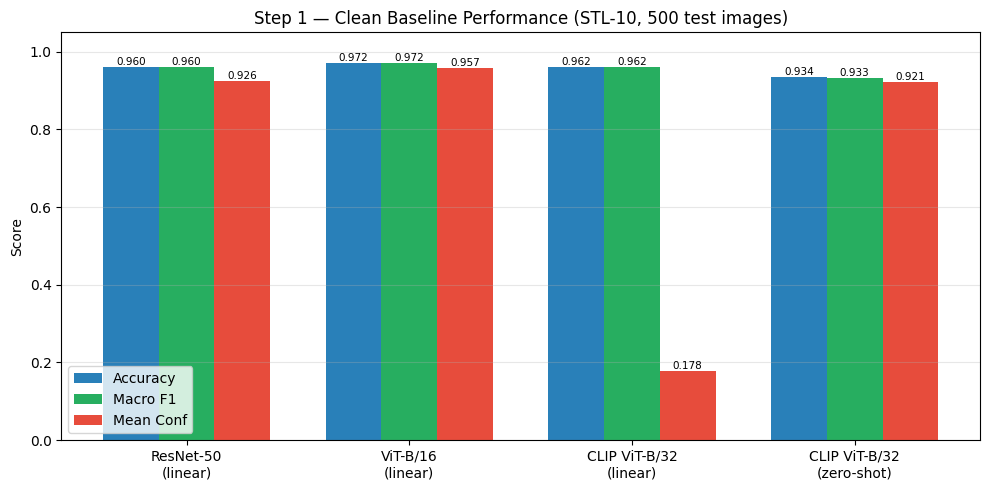

Saved → /content/drive/MyDrive/atml_assignment1/task1/results/step1_baseline_bar.png


In [19]:
# ── Step 1: Baseline bar chart ─────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

labels = ['ResNet-50\n(linear)', 'ViT-B/16\n(linear)',
          'CLIP ViT-B/32\n(linear)', 'CLIP ViT-B/32\n(zero-shot)']
keys   = ['resnet_linear', 'vit_linear', 'clip_linear', 'clip_zeroshot']

accs = [baseline_results[k]['accuracy']  for k in keys]
f1s  = [baseline_results[k]['macro_f1']  for k in keys]
conf = [baseline_results[k]['mean_max_conf'] for k in keys]

x    = np.arange(len(labels))
w    = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - w,   accs, w, label='Accuracy',   color='#2980b9')
ax.bar(x,        f1s, w, label='Macro F1',   color='#27ae60')
ax.bar(x + w,   conf, w, label='Mean Conf',  color='#e74c3c')

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=10)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('Step 1 — Clean Baseline Performance (STL-10, 500 test images)')
ax.legend()
ax.grid(axis='y', alpha=0.3)

for bar in ax.patches:
    ax.annotate(f'{bar.get_height():.3f}',
                (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                ha='center', va='bottom', fontsize=7.5)

plt.tight_layout()
path = os.path.join(OUTPUT_DIR, 'step1_baseline_bar.png')
plt.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved → {path}")

In [20]:
# ── Step 2: Color Bias ─────────────────────────────────────────────────────
# Intervention A: Grayscale  — removes all color, keeps luminance/structure
# Intervention B: Hue Rotate — shifts hue by 90° while keeping saturation
#                               and value, changing which color is present
#                               without altering geometry or brightness

import torchvision.transforms.functional as TF

def apply_grayscale(images: torch.Tensor) -> torch.Tensor:
    """Convert (N,3,224,224) [0,1] RGB to grayscale, broadcast back to 3ch."""
    gray = TF.rgb_to_grayscale(images, num_output_channels=3)
    return gray

def apply_hue_rotate(images: torch.Tensor,
                     hue_factor: float = 0.25) -> torch.Tensor:
    """
    Shift hue by hue_factor ∈ [-0.5, 0.5].
    0.25 corresponds to a ~90° rotation around the colour wheel.
    Geometry, luminance, and saturation are preserved.
    """
    rotated = torch.stack([TF.adjust_hue(img, hue_factor) for img in images])
    return rotated

def prediction_consistency(preds_clean: np.ndarray,
                            preds_transformed: np.ndarray) -> float:
    """Fraction of images whose predicted class did not change."""
    return float((preds_clean == preds_transformed).mean())

In [21]:
# ── Apply both interventions ───────────────────────────────────────────────
print("Applying color interventions...")
gray_images = apply_grayscale(EVAL_IMAGES)
hue_images  = apply_hue_rotate(EVAL_IMAGES, hue_factor=0.25)
print(f"  Grayscale images : {tuple(gray_images.shape)}")
print(f"  Hue-rotated images : {tuple(hue_images.shape)}")

Applying color interventions...
  Grayscale images : (500, 3, 224, 224)
  Hue-rotated images : (500, 3, 224, 224)


In [22]:
# ── Evaluate all models on both interventions ──────────────────────────────
color_results = {}

for transform_name, transformed_imgs in [("grayscale", gray_images),
                                          ("hue_rotate", hue_images)]:
    color_results[transform_name] = {}
    print(f"\n  [{transform_name}]")

    # Linear probes
    for model_name in ["resnet", "vit", "clip"]:
        result = evaluate(model_name, transformed_imgs, EVAL_LABELS,
                          head=heads[model_name])
        preds_clean = baseline_results[f"{model_name}_linear"]["predictions"]
        consistency = prediction_consistency(preds_clean, result["predictions"])
        result["consistency"] = consistency
        color_results[transform_name][f"{model_name}_linear"] = result
        print(f"    {model_name:<8} linear | "
              f"acc={result['accuracy']:.4f} "
              f"(Δ={result['accuracy'] - baseline_results[f'{model_name}_linear']['accuracy']:+.4f}) | "
              f"consistency={consistency:.4f}")

    # CLIP zero-shot
    result = evaluate_clip_zeroshot(transformed_imgs, EVAL_LABELS)
    preds_clean = baseline_results["clip_zeroshot"]["predictions"]
    consistency = prediction_consistency(preds_clean, result["predictions"])
    result["consistency"] = consistency
    color_results[transform_name]["clip_zeroshot"] = result
    print(f"    {'clip':<8} zero-shot | "
          f"acc={result['accuracy']:.4f} "
          f"(Δ={result['accuracy'] - baseline_results['clip_zeroshot']['accuracy']:+.4f}) | "
          f"consistency={consistency:.4f}")


  [grayscale]
    resnet   linear | acc=0.9440 (Δ=-0.0160) | consistency=0.9520
    vit      linear | acc=0.9380 (Δ=-0.0340) | consistency=0.9500
    clip     linear | acc=0.9200 (Δ=-0.0420) | consistency=0.9260
    clip     zero-shot | acc=0.8960 (Δ=-0.0380) | consistency=0.9140

  [hue_rotate]
    resnet   linear | acc=0.9320 (Δ=-0.0280) | consistency=0.9440
    vit      linear | acc=0.9360 (Δ=-0.0360) | consistency=0.9440
    clip     linear | acc=0.9280 (Δ=-0.0340) | consistency=0.9440
    clip     zero-shot | acc=0.9000 (Δ=-0.0340) | consistency=0.9240


In [23]:

# ── Summary table ──────────────────────────────────────────────────────────
print("\n" + "=" * 72)
print("  COLOR BIAS SUMMARY")
print("=" * 72)
print(f"  {'Model':<28} {'Clean':>6} {'Gray Acc':>9} {'Gray Δ':>7} "
      f"{'Gray Con':>9} {'Hue Acc':>8} {'Hue Δ':>7} {'Hue Con':>8}")
print("  " + "-" * 67)

for key, name in DISPLAY_NAMES.items():
    clean_acc = baseline_results[key]["accuracy"]
    g = color_results["grayscale"].get(key, {})
    h = color_results["hue_rotate"].get(key, {})
    if not g:
        continue
    print(f"  {name:<28} {clean_acc:>6.4f} "
          f"{g['accuracy']:>9.4f} {g['accuracy']-clean_acc:>+7.4f} "
          f"{g['consistency']:>9.4f} "
          f"{h['accuracy']:>8.4f} {h['accuracy']-clean_acc:>+7.4f} "
          f"{h['consistency']:>8.4f}")

print("=" * 72)


  COLOR BIAS SUMMARY
  Model                         Clean  Gray Acc  Gray Δ  Gray Con  Hue Acc   Hue Δ  Hue Con
  -------------------------------------------------------------------
  ResNet-50       (linear)     0.9600    0.9440 -0.0160    0.9520   0.9320 -0.0280   0.9440
  ViT-B/16        (linear)     0.9720    0.9380 -0.0340    0.9500   0.9360 -0.0360   0.9440
  CLIP ViT-B/32   (linear)     0.9620    0.9200 -0.0420    0.9260   0.9280 -0.0340   0.9440
  CLIP ViT-B/32   (zero-shot)  0.9340    0.8960 -0.0380    0.9140   0.9000 -0.0340   0.9240


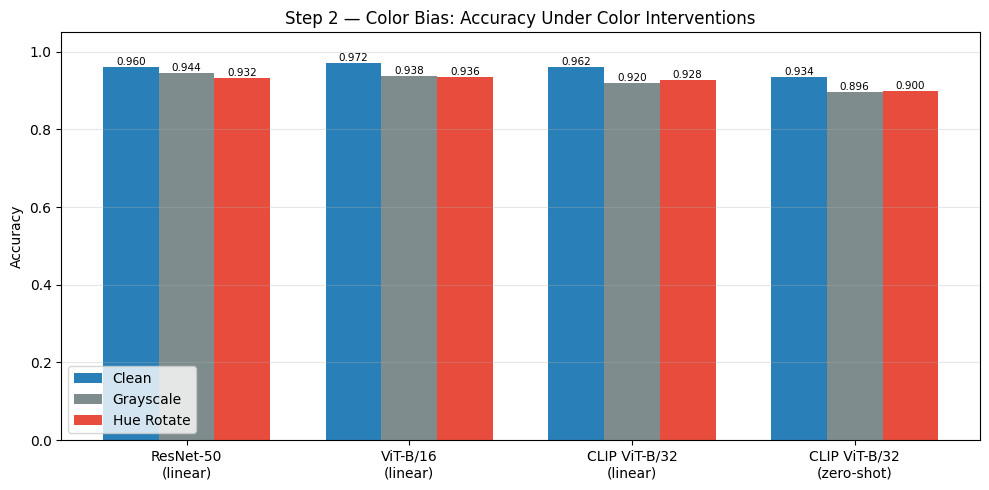

Saved → /content/drive/MyDrive/atml_assignment1/task1/results/step2_color_bias_bar.png


In [24]:
# ── Step 2: Color bias bar chart ───────────────────────────────────────────

keys     = ['resnet_linear', 'vit_linear', 'clip_linear', 'clip_zeroshot']
labels   = ['ResNet-50\n(linear)', 'ViT-B/16\n(linear)',
            'CLIP ViT-B/32\n(linear)', 'CLIP ViT-B/32\n(zero-shot)']

clean_accs = [baseline_results[k]['accuracy']                   for k in keys]
gray_accs  = [color_results['grayscale'][k]['accuracy']         for k in keys]
hue_accs   = [color_results['hue_rotate'][k]['accuracy']        for k in keys]

x = np.arange(len(labels))
w = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - w,  clean_accs, w, label='Clean',       color='#2980b9')
ax.bar(x,      gray_accs,  w, label='Grayscale',   color='#7f8c8d')
ax.bar(x + w,  hue_accs,   w, label='Hue Rotate',  color='#e74c3c')

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=10)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Accuracy')
ax.set_title('Step 2 — Color Bias: Accuracy Under Color Interventions')
ax.legend()
ax.grid(axis='y', alpha=0.3)

for bar in ax.patches:
    ax.annotate(f'{bar.get_height():.3f}',
                (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                ha='center', va='bottom', fontsize=7.5)

plt.tight_layout()
path = os.path.join(OUTPUT_DIR, 'step2_color_bias_bar.png')
plt.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved → {path}")

In [25]:
# ── Save ───────────────────────────────────────────────────────────────────
save = {}
for t, models in color_results.items():
    save[t] = {}
    for k, r in models.items():
        save[t][k] = {m: v for m, v in r.items()
                      if m not in ("predictions", "probabilities")}

out_path = os.path.join(OUTPUT_DIR, "step2_color_bias.json")
with open(out_path, "w") as f:
    json.dump(save, f, indent=2)
print(f"\n  Saved → {out_path}")


  Saved → /content/drive/MyDrive/atml_assignment1/task1/results/step2_color_bias.json


In [26]:
# ── Step 3a: Download AdaIN weights from GitHub Releases (no gdown needed) ──

import subprocess, os

ADAIN_DIR    = os.path.join(DRIVE_ROOT, 'task1', 'adain_weights')
os.makedirs(ADAIN_DIR, exist_ok=True)
DECODER_PATH = os.path.join(ADAIN_DIR, 'decoder.pth')
VGG_PATH     = os.path.join(ADAIN_DIR, 'vgg_normalised.pth')

BASE = "https://github.com/naoto0804/pytorch-AdaIN/releases/download/v0.0.0"

if not os.path.exists(DECODER_PATH):
    print("Downloading decoder...")
    subprocess.run(["wget", "-q", "--show-progress", "-O", DECODER_PATH,
                    f"{BASE}/decoder.pth"], check=True)

if not os.path.exists(VGG_PATH):
    print("Downloading VGG...")
    subprocess.run(["wget", "-q", "--show-progress", "-O", VGG_PATH,
                    f"{BASE}/vgg_normalised.pth"], check=True)

print(f"Decoder : {os.path.getsize(DECODER_PATH)/1e6:.1f} MB")
print(f"VGG     : {os.path.getsize(VGG_PATH)/1e6:.1f} MB")
print("Done.")

Decoder : 14.0 MB
VGG     : 80.1 MB
Done.


In [27]:
# ── Step 3b: AdaIN network architecture and stylize function ───────────────
# VGG encoder uses vgg_normalised.pth which has ImageNet normalization
# absorbed into its first conv layer — so input is plain [0, 1] images.

def calc_mean_std(feat, eps=1e-5):
    N, C = feat.size()[:2]
    std  = feat.view(N, C, -1).var(dim=2).add_(eps).sqrt_().view(N, C, 1, 1)
    mean = feat.view(N, C, -1).mean(dim=2).view(N, C, 1, 1)
    return mean, std

def adain_transform(content_feat, style_feat):
    """Transfer style statistics onto content features."""
    c_mean, c_std = calc_mean_std(content_feat)
    s_mean, s_std = calc_mean_std(style_feat)
    normalized = (content_feat - c_mean.expand_as(content_feat)) \
                  / c_std.expand_as(content_feat)
    return normalized * s_std.expand_as(content_feat) \
                      + s_mean.expand_as(content_feat)

# VGG encoder — up to relu4_1
vgg_enc = nn.Sequential(
    nn.Conv2d(3, 3, (1, 1)),
    nn.ReflectionPad2d((1, 1, 1, 1)),
    nn.Conv2d(3, 64, (3, 3)),   nn.ReLU(),   # relu1_1
    nn.ReflectionPad2d((1, 1, 1, 1)),
    nn.Conv2d(64, 64, (3, 3)),  nn.ReLU(),   # relu1_2
    nn.MaxPool2d((2, 2), (2, 2), (0, 0), ceil_mode=True),
    nn.ReflectionPad2d((1, 1, 1, 1)),
    nn.Conv2d(64, 128, (3, 3)), nn.ReLU(),   # relu2_1
    nn.ReflectionPad2d((1, 1, 1, 1)),
    nn.Conv2d(128, 128, (3, 3)),nn.ReLU(),   # relu2_2
    nn.MaxPool2d((2, 2), (2, 2), (0, 0), ceil_mode=True),
    nn.ReflectionPad2d((1, 1, 1, 1)),
    nn.Conv2d(128, 256, (3, 3)),nn.ReLU(),   # relu3_1
    nn.ReflectionPad2d((1, 1, 1, 1)),
    nn.Conv2d(256, 256, (3, 3)),nn.ReLU(),
    nn.ReflectionPad2d((1, 1, 1, 1)),
    nn.Conv2d(256, 256, (3, 3)),nn.ReLU(),
    nn.ReflectionPad2d((1, 1, 1, 1)),
    nn.Conv2d(256, 256, (3, 3)),nn.ReLU(),
    nn.MaxPool2d((2, 2), (2, 2), (0, 0), ceil_mode=True),
    nn.ReflectionPad2d((1, 1, 1, 1)),
    nn.Conv2d(256, 512, (3, 3)),nn.ReLU(),   # relu4_1 ← output
)

# Decoder — symmetric to encoder
adain_dec = nn.Sequential(
    nn.ReflectionPad2d((1, 1, 1, 1)), nn.Conv2d(512, 256, (3, 3)), nn.ReLU(),
    nn.Upsample(scale_factor=2, mode='nearest'),
    nn.ReflectionPad2d((1, 1, 1, 1)), nn.Conv2d(256, 256, (3, 3)), nn.ReLU(),
    nn.ReflectionPad2d((1, 1, 1, 1)), nn.Conv2d(256, 256, (3, 3)), nn.ReLU(),
    nn.ReflectionPad2d((1, 1, 1, 1)), nn.Conv2d(256, 256, (3, 3)), nn.ReLU(),
    nn.ReflectionPad2d((1, 1, 1, 1)), nn.Conv2d(256, 128, (3, 3)), nn.ReLU(),
    nn.Upsample(scale_factor=2, mode='nearest'),
    nn.ReflectionPad2d((1, 1, 1, 1)), nn.Conv2d(128, 128, (3, 3)), nn.ReLU(),
    nn.ReflectionPad2d((1, 1, 1, 1)), nn.Conv2d(128, 64,  (3, 3)), nn.ReLU(),
    nn.Upsample(scale_factor=2, mode='nearest'),
    nn.ReflectionPad2d((1, 1, 1, 1)), nn.Conv2d(64,  64,  (3, 3)), nn.ReLU(),
    nn.ReflectionPad2d((1, 1, 1, 1)), nn.Conv2d(64,   3,  (3, 3)),
)

vgg_enc.load_state_dict(torch.load(VGG_PATH,     map_location='cpu'), strict=False)
adain_dec.load_state_dict(torch.load(DECODER_PATH, map_location='cpu'))

vgg_enc   = vgg_enc.to(DEVICE).eval()
adain_dec = adain_dec.to(DEVICE).eval()
for p in list(vgg_enc.parameters()) + list(adain_dec.parameters()):
    p.requires_grad = False

print("AdaIN encoder and decoder ready.")

@torch.no_grad()
def stylize(content: torch.Tensor, style: torch.Tensor,
            alpha: float = 1.0) -> torch.Tensor:
    """
    content, style: (1, 3, 224, 224) in [0, 1]
    alpha=1.0 → full style transfer
    Returns: (1, 3, 224, 224) in [0, 1]
    """
    cf = vgg_enc(content.to(DEVICE))
    sf = vgg_enc(style.to(DEVICE))
    t  = adain_transform(cf, sf)
    t  = alpha * t + (1 - alpha) * cf
    return adain_dec(t).clamp(0, 1).cpu()

AdaIN encoder and decoder ready.


In [28]:
# ── Step 3c: Visual rejection rule + generate cue conflicts ────────────────

# Rejection rule defined BEFORE any model evaluation
def visual_reject(img: torch.Tensor) -> tuple[bool, str]:
    """
    img: (3, 224, 224) in [0, 1].
    Returns (reject, reason).
    """
    if torch.isnan(img).any() or torch.isinf(img).any():
        return True, "NaN/Inf"
    std = img.std().item()
    if std < 0.05:
        return True, f"std={std:.3f}<0.05"
    mean = img.mean().item()
    if mean < 0.05 or mean > 0.95:
        return True, f"mean={mean:.3f} out of [0.05,0.95]"
    sat = ((img > 0.99) | (img < 0.01)).float().mean().item()
    if sat > 0.05:
        return True, f"sat_frac={sat:.3f}>0.05"
    return False, ""

print("Rejection rule: NaN/Inf | std<0.05 | mean outside [0.05,0.95] | >5% saturated")

# ── Class pairs ────────────────────────────────────────────────────────────
CLASS_PAIRS = [
    (3, 5),  # cat   ↔ dog
    (0, 8),  # airplane ↔ ship
    (2, 9),  # car   ↔ truck
    (1, 6),  # bird  ↔ horse
    (4, 7),  # deer  ↔ monkey
]
N_PER_DIRECTION = 30  # 5 pairs × 2 dirs × 30 = 300 attempts

# Cache paths on Drive
CC_IMAGES_PATH = os.path.join(DRIVE_ROOT, 'task1', 'cue_conflicts', 'cc_images.pt')
CC_META_PATH   = os.path.join(DRIVE_ROOT, 'task1', 'cue_conflicts', 'cc_metadata.json')
os.makedirs(os.path.dirname(CC_IMAGES_PATH), exist_ok=True)

# ── Load from cache or generate ────────────────────────────────────────────
if os.path.exists(CC_IMAGES_PATH) and os.path.exists(CC_META_PATH):
    print("Loading cached cue-conflict images from Drive...")
    CC_IMAGES = torch.load(CC_IMAGES_PATH, map_location='cpu')
    with open(CC_META_PATH) as f:
        cc_meta = json.load(f)
    cue_conflicts  = cc_meta["conflicts"]
    accepted_count = cc_meta["accepted"]
    rejected_count = cc_meta["rejected"]
    CC_CONTENT = torch.tensor([d["content_cls"] for d in cue_conflicts])
    CC_STYLE   = torch.tensor([d["style_cls"]   for d in cue_conflicts])
    print(f"  Loaded {len(CC_IMAGES)} images from cache.")

else:
    print("Generating cue-conflict images...")

    # Indices per class in EVAL_IMAGES
    eval_labels_np = EVAL_LABELS.numpy()
    class_indices  = {c: np.where(eval_labels_np == c)[0]
                      for c in range(NUM_CLASSES)}

    set_seed(SEED)
    cue_conflicts  = []
    cc_images_list = []
    accepted_count = 0
    rejected_count = 0

    for (cls_a, cls_b) in CLASS_PAIRS:
        for (content_cls, style_cls) in [(cls_a, cls_b), (cls_b, cls_a)]:
            c_idxs = np.random.choice(class_indices[content_cls],
                                      N_PER_DIRECTION, replace=False)
            s_idxs = np.random.choice(class_indices[style_cls],
                                      N_PER_DIRECTION, replace=False)

            for ci, si in zip(c_idxs, s_idxs):
                c_img = EVAL_IMAGES[ci].unsqueeze(0)
                s_img = EVAL_IMAGES[si].unsqueeze(0)
                out   = stylize(c_img, s_img, alpha=1.0).squeeze(0)

                reject, reason = visual_reject(out)
                if reject:
                    rejected_count += 1
                    continue

                cue_conflicts.append({
                    "content_cls" : int(content_cls),
                    "style_cls"   : int(style_cls),
                    "content_name": STL10_CLASSES[content_cls],
                    "style_name"  : STL10_CLASSES[style_cls],
                    "eval_content_idx": int(ci),
                    "eval_style_idx"  : int(si),
                })
                cc_images_list.append(out)
                accepted_count += 1

    CC_IMAGES  = torch.stack(cc_images_list)
    CC_CONTENT = torch.tensor([d["content_cls"] for d in cue_conflicts])
    CC_STYLE   = torch.tensor([d["style_cls"]   for d in cue_conflicts])

    # Save to Drive
    torch.save(CC_IMAGES, CC_IMAGES_PATH)
    with open(CC_META_PATH, 'w') as f:
        json.dump({"conflicts": cue_conflicts,
                   "accepted": accepted_count,
                   "rejected": rejected_count}, f, indent=2)
    print(f"  Saved to Drive.")

print(f"\n  Accepted : {accepted_count}")
print(f"  Rejected : {rejected_count}")
print(f"  CC_IMAGES: {tuple(CC_IMAGES.shape)}")

Rejection rule: NaN/Inf | std<0.05 | mean outside [0.05,0.95] | >5% saturated
Loading cached cue-conflict images from Drive...
  Loaded 246 images from cache.

  Accepted : 246
  Rejected : 54
  CC_IMAGES: (246, 3, 224, 224)


In [29]:
# ── Step 3d: Evaluate shape bias ──────────────────────────────────────────

def eval_shape_bias(model_name, images, content_labels, style_labels,
                    head=None):
    all_preds = []
    wrapper   = MODELS[model_name]

    for i in range(0, len(images), 64):
        xb = images[i:i+64]
        if head is not None:
            feats  = wrapper.get_features(xb)
            logits = head(feats.to(DEVICE))
        else:
            logits, _ = clip_zero_shot(xb)
        all_preds.append(logits.argmax(1).cpu())

    preds      = torch.cat(all_preds).numpy()
    content_np = content_labels.numpy()
    style_np   = style_labels.numpy()

    n_shape   = int((preds == content_np).sum())
    n_texture = int(((preds == style_np) & (preds != content_np)).sum())
    n_other   = len(preds) - n_shape - n_texture
    n_total   = len(preds)

    shape_bias = 100 * n_shape / (n_shape + n_texture) \
                 if (n_shape + n_texture) > 0 else 0.0
    coverage   = 100 * (n_shape + n_texture) / n_total

    return {"n_shape": n_shape, "n_texture": n_texture,
            "n_other": n_other, "n_total": n_total,
            "shape_bias": shape_bias, "coverage": coverage,
            "predictions": preds}

shape_bias_results = {}

for model_name in ["resnet", "vit", "clip"]:
    r = eval_shape_bias(model_name, CC_IMAGES, CC_CONTENT, CC_STYLE,
                        head=heads[model_name])
    shape_bias_results[f"{model_name}_linear"] = r

r = eval_shape_bias("clip", CC_IMAGES, CC_CONTENT, CC_STYLE, head=None)
shape_bias_results["clip_zeroshot"] = r

In [30]:
# ── Step 3e: Informative cue-conflict examples ─────────────────────────────
# Collect all model predictions on CC_IMAGES

cc_preds = {}
for model_name in ["resnet", "vit", "clip"]:
    all_p = []
    wrapper = MODELS[model_name]
    for i in range(0, len(CC_IMAGES), 64):
        xb = CC_IMAGES[i:i+64]
        feats  = wrapper.get_features(xb)
        logits = heads[model_name](feats.to(DEVICE))
        all_p.append(logits.argmax(1).cpu())
    cc_preds[model_name] = torch.cat(all_p).numpy()

# Zero-shot
all_p = []
for i in range(0, len(CC_IMAGES), 64):
    logits, _ = clip_zero_shot(CC_IMAGES[i:i+64])
    all_p.append(logits.argmax(1).cpu())
cc_preds["clip_zs"] = torch.cat(all_p).numpy()

content_np = CC_CONTENT.numpy()
style_np   = CC_STYLE.numpy()

# Categorize each image
def categorize(pred, content, style):
    if pred == content: return "shape"
    if pred == style:   return "texture"
    return "other"

categories = {m: [categorize(cc_preds[m][i], content_np[i], style_np[i])
                  for i in range(len(CC_IMAGES))]
              for m in cc_preds}

# Find interesting examples
agreements_shape, disagreements, failures = [], [], []

for i in range(len(CC_IMAGES)):
    cats = [categories[m][i] for m in ["resnet", "vit", "clip"]]
    if all(c == "shape" for c in cats):
        agreements_shape.append(i)
    elif len(set(cats)) > 1:          # models disagree
        disagreements.append(i)
    elif all(c == "other" for c in cats):
        failures.append(i)

print(f"Shape agreements : {len(agreements_shape)}")
print(f"Disagreements    : {len(disagreements)}")
print(f"All-failure cases: {len(failures)}")

Shape agreements : 105
Disagreements    : 116
All-failure cases: 21


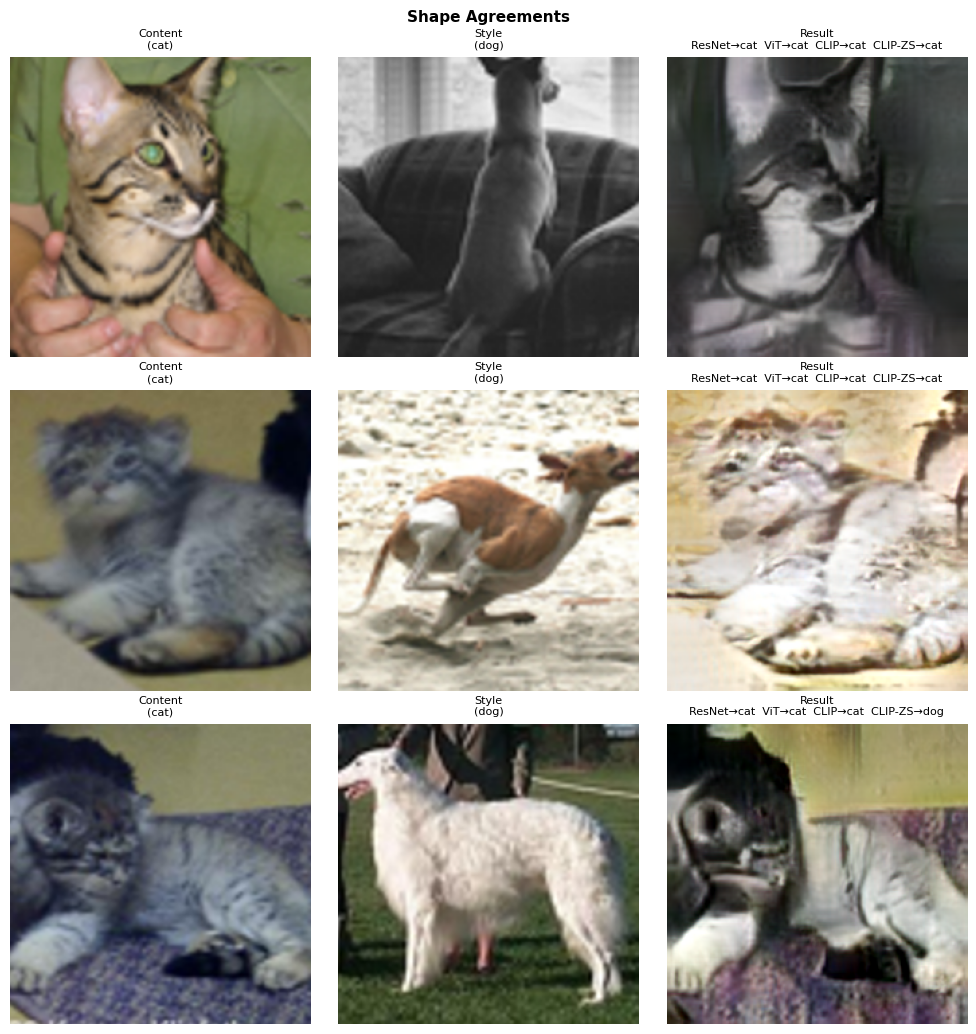

  Saved → /content/drive/MyDrive/atml_assignment1/task1/results/step3e_shape_agreements.png


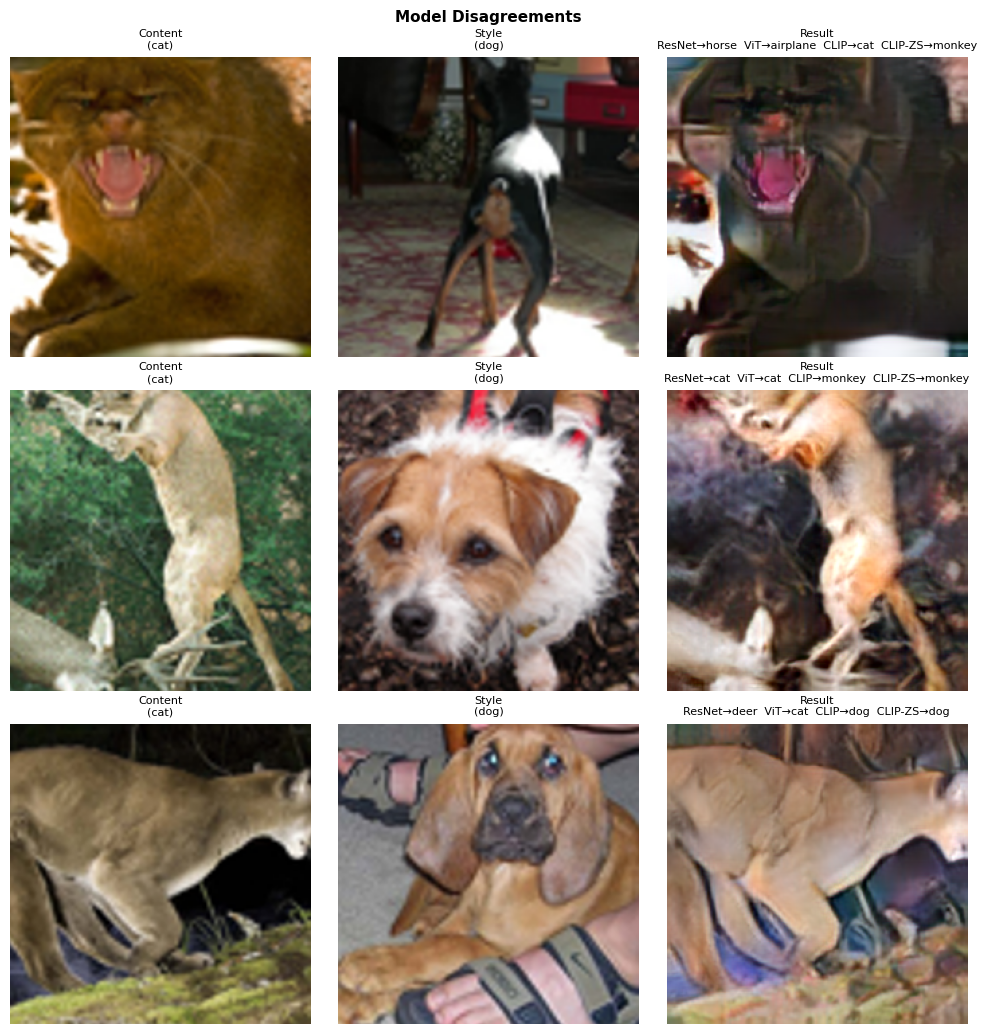

  Saved → /content/drive/MyDrive/atml_assignment1/task1/results/step3e_model_disagreements.png


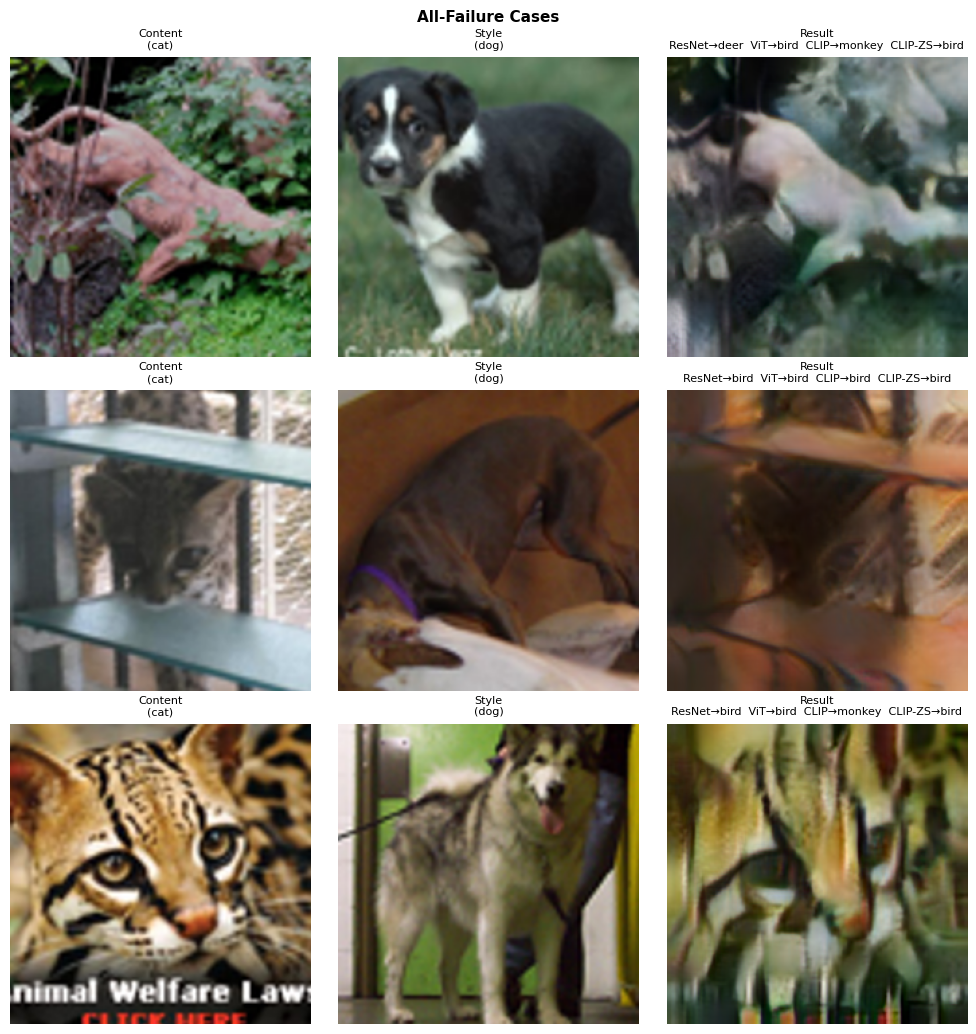

  Saved → /content/drive/MyDrive/atml_assignment1/task1/results/step3e_all-failure_cases.png


In [31]:
# ── Plot 3 of each ─────────────────────────────────────────────────────────

def show_cc_examples(indices, title, n=3):
    fig, axes = plt.subplots(n, 3, figsize=(10, n * 3.5))
    if n == 1:
        axes = axes[np.newaxis, :]

    for row, idx in enumerate(indices[:n]):
        meta = cue_conflicts[idx]

        # Get the original content and style images using stored indices
        content_img = EVAL_IMAGES[meta['eval_content_idx']].permute(1,2,0).numpy()
        style_img   = EVAL_IMAGES[meta['eval_style_idx']  ].permute(1,2,0).numpy()
        result_img  = CC_IMAGES[idx].permute(1,2,0).numpy()

        preds_str = (f"ResNet→{STL10_CLASSES[cc_preds['resnet'][idx]]}  "
                     f"ViT→{STL10_CLASSES[cc_preds['vit'][idx]]}  "
                     f"CLIP→{STL10_CLASSES[cc_preds['clip'][idx]]}  "
                     f"CLIP-ZS→{STL10_CLASSES[cc_preds['clip_zs'][idx]]}")

        for col, (img, col_title) in enumerate([
            (content_img, f"Content\n({meta['content_name']})"),
            (style_img,   f"Style\n({meta['style_name']})"),
            (result_img,  f"Result\n{preds_str}"),
        ]):
            axes[row, col].imshow(img.clip(0,1))
            axes[row, col].set_title(col_title, fontsize=8)
            axes[row, col].axis('off')

    fig.suptitle(title, fontsize=11, fontweight='bold')
    plt.tight_layout()
    save_title = title.lower().replace(' ', '_')
    path = os.path.join(OUTPUT_DIR, f'step3e_{save_title}.png')
    plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"  Saved → {path}")

show_cc_examples(agreements_shape, "Shape Agreements")
show_cc_examples(disagreements,    "Model Disagreements")
show_cc_examples(failures,         "All-Failure Cases")

In [32]:
# ── Summary ────────────────────────────────────────────────────────────────
print("=" * 65)
print("  SHAPE vs TEXTURE — CUE CONFLICT RESULTS")
print("=" * 65)
print(f"  {'Model':<28} {'Shape':>6} {'Tex':>5} {'Other':>6} "
      f"{'Bias%':>7} {'Cover%':>7}")
print("  " + "-" * 60)
for key, name in DISPLAY_NAMES.items():
    r = shape_bias_results[key]
    print(f"  {name:<28} {r['n_shape']:>6} {r['n_texture']:>5} "
          f"{r['n_other']:>6} {r['shape_bias']:>7.1f} {r['coverage']:>7.1f}")
print("=" * 65)

  SHAPE vs TEXTURE — CUE CONFLICT RESULTS
  Model                         Shape   Tex  Other   Bias%  Cover%
  ------------------------------------------------------------
  ResNet-50       (linear)        127    44     75    74.3    69.5
  ViT-B/16        (linear)        175    23     48    88.4    80.5
  CLIP ViT-B/32   (linear)        173    24     49    87.8    80.1
  CLIP ViT-B/32   (zero-shot)     154    32     60    82.8    75.6


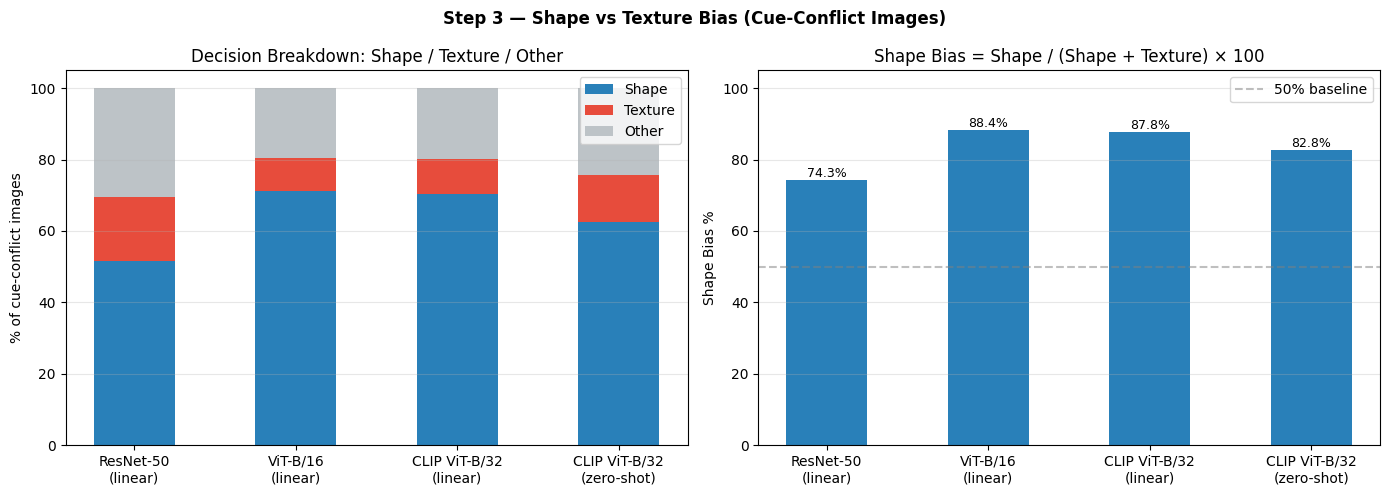

Saved → /content/drive/MyDrive/atml_assignment1/task1/results/step3_shape_bias_chart.png


In [33]:
# ── Step 3: Shape bias stacked bar chart ───────────────────────────────────
keys   = ['resnet_linear', 'vit_linear', 'clip_linear', 'clip_zeroshot']
labels = ['ResNet-50\n(linear)', 'ViT-B/16\n(linear)',
          'CLIP ViT-B/32\n(linear)', 'CLIP ViT-B/32\n(zero-shot)']

n_total   = shape_bias_results['resnet_linear']['n_total']
shape_pct = [100 * shape_bias_results[k]['n_shape']   / n_total for k in keys]
tex_pct   = [100 * shape_bias_results[k]['n_texture'] / n_total for k in keys]
other_pct = [100 * shape_bias_results[k]['n_other']   / n_total for k in keys]
bias_pct  = [shape_bias_results[k]['shape_bias'] for k in keys]

x = np.arange(len(labels))
w = 0.5

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: stacked bar
ax1.bar(x, shape_pct, w, label='Shape',   color='#2980b9')
ax1.bar(x, tex_pct,   w, label='Texture', color='#e74c3c',
        bottom=shape_pct)
ax1.bar(x, other_pct, w, label='Other',   color='#bdc3c7',
        bottom=[s+t for s,t in zip(shape_pct, tex_pct)])

ax1.set_xticks(x)
ax1.set_xticklabels(labels, fontsize=10)
ax1.set_ylim(0, 105)
ax1.set_ylabel('% of cue-conflict images')
ax1.set_title('Decision Breakdown: Shape / Texture / Other')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Right: shape bias % only
bars = ax2.bar(x, bias_pct, w, color='#2980b9')
ax2.set_xticks(x)
ax2.set_xticklabels(labels, fontsize=10)
ax2.set_ylim(0, 105)
ax2.set_ylabel('Shape Bias %')
ax2.set_title('Shape Bias = Shape / (Shape + Texture) × 100')
ax2.axhline(50, color='gray', linestyle='--', alpha=0.5, label='50% baseline')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

for bar in bars:
    ax2.annotate(f'{bar.get_height():.1f}%',
                 (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                 ha='center', va='bottom', fontsize=9)

plt.suptitle('Step 3 — Shape vs Texture Bias (Cue-Conflict Images)', 
             fontsize=12, fontweight='bold')
plt.tight_layout()
path = os.path.join(OUTPUT_DIR, 'step3_shape_bias_chart.png')
plt.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved → {path}")

In [34]:
# Save
save = {k: {m: v for m, v in r.items() if m != "predictions"}
        for k, r in shape_bias_results.items()}
out_path = os.path.join(OUTPUT_DIR, "step3_shape_texture.json")
with open(out_path, "w") as f:
    json.dump({"results": save, "accepted": accepted_count,
               "rejected": rejected_count, "n_total": len(CC_IMAGES),
               "class_pairs": CLASS_PAIRS}, f, indent=2)
print(f"\n  Saved → {out_path}")


  Saved → /content/drive/MyDrive/atml_assignment1/task1/results/step3_shape_texture.json


In [35]:
# ── Step 4: Translation ─────────────────────────────────────────────────────

import torch.nn.functional as F

DELTAS     = [0, 8, 16, 32]
DIRECTIONS = ['right', 'left', 'up', 'down']

def apply_translation(images: torch.Tensor, delta: int, direction: str) -> torch.Tensor:
    """
    Translate a batch of images by `delta` pixels in `direction`
    using reflection padding + shifted crop.
    images : (N, 3, H, W) in [0, 1]
    Returns: (N, 3, H, W) in [0, 1]
    """
    if delta == 0:
        return images.clone()

    N, C, H, W = images.shape
    # Pad all sides by delta with reflection
    padded = F.pad(images, (delta, delta, delta, delta), mode='reflect')
    # (N, C, H+2δ, W+2δ)

    # Crop offset so content appears shifted in the chosen direction
    offsets = {
        'right': (delta, 0),        # object moves right → reveal left reflection
        'left' : (delta, 2 * delta),# object moves left  → reveal right reflection
        'down' : (0,     delta),    # object moves down  → reveal top reflection
        'up'   : (2 * delta, delta),# object moves up    → reveal bottom reflection
    }
    top, left = offsets[direction]
    return padded[:, :, top:top + H, left:left + W]

In [36]:
# ── Cache ────────────────────────────────────────────────────────────────────

TRANS_CACHE = os.path.join(OUTPUT_DIR, 'step4_translation.json')

if os.path.exists(TRANS_CACHE):
    print("Loading cached translation results...")
    with open(TRANS_CACHE) as f:
        translation_results = json.load(f)
    # json keys are strings — convert delta keys back to int
    translation_results = {
        model: {int(d): v for d, v in deltas.items()}
        for model, deltas in translation_results.items()
    }
    print("  Done.")

else:
    print("Running translation experiment...")

    # Clean predictions for consistency reference
    clean_preds = {
        'resnet_linear' : np.array(baseline_results['resnet_linear']['predictions']),
        'vit_linear'    : np.array(baseline_results['vit_linear']['predictions']),
        'clip_linear'   : np.array(baseline_results['clip_linear']['predictions']),
        'clip_zeroshot' : np.array(baseline_results['clip_zeroshot']['predictions']),
    }

    translation_results = {}

    for model_name in ['resnet', 'vit', 'clip']:
        eval_types = ['linear', 'zeroshot'] if model_name == 'clip' else ['linear']
        for eval_type in eval_types:
            key = f'{model_name}_{eval_type}'
            translation_results[key] = {}

            for delta in DELTAS:
                dir_accs, dir_cons = [], []

                for direction in DIRECTIONS:
                    imgs_t = apply_translation(EVAL_IMAGES, delta, direction)

                    if eval_type == 'linear':
                        res = evaluate(model_name, imgs_t, EVAL_LABELS,
                                       head=heads[model_name])
                    else:
                        res = evaluate_clip_zeroshot(imgs_t, EVAL_LABELS)

                    cons = prediction_consistency(clean_preds[key],
                                                  res['predictions'])
                    dir_accs.append(res['accuracy'])
                    dir_cons.append(cons)

                translation_results[key][delta] = {
                    'accuracy'    : float(np.mean(dir_accs)),
                    'consistency' : float(np.mean(dir_cons)),
                    'acc_per_dir' : dir_accs,
                    'cons_per_dir': dir_cons,
                }
                print(f"  {key:22s} | δ={delta:2d}px | "
                      f"acc={np.mean(dir_accs):.4f} | "
                      f"cons={np.mean(dir_cons):.4f}")

    # Save (convert int keys to str for JSON)
    save = {m: {str(d): v for d, v in dv.items()}
            for m, dv in translation_results.items()}
    with open(TRANS_CACHE, 'w') as f:
        json.dump(save, f, indent=2)
    print(f"\n  Saved → {TRANS_CACHE}")

Loading cached translation results...
  Done.


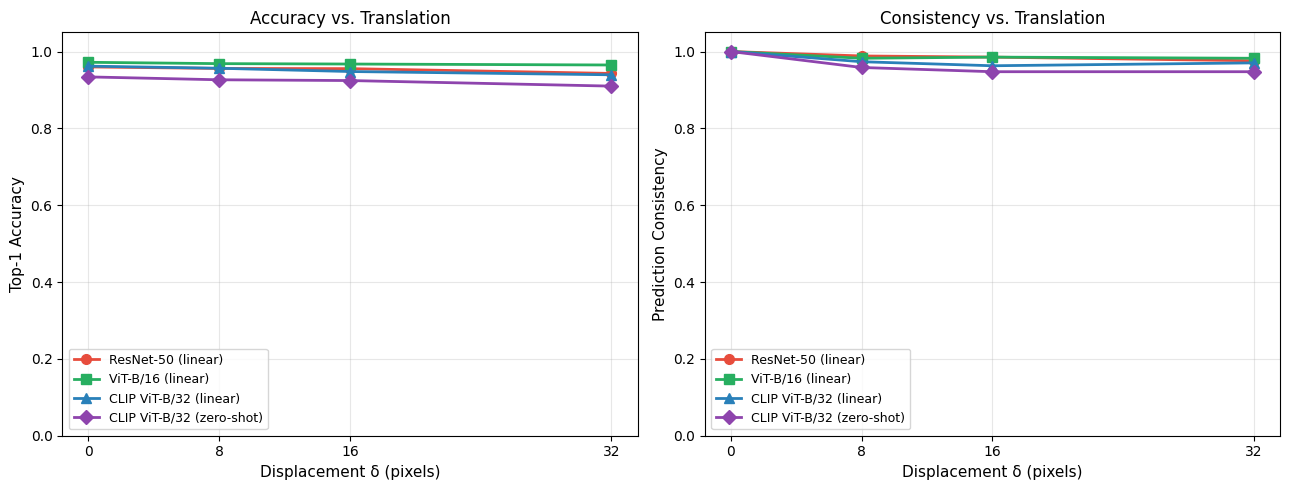

Saved → /content/drive/MyDrive/atml_assignment1/task1/results/step4_translation_plot.png


In [37]:
# ── Plot ─────────────────────────────────────────────────────────────────────

STYLE = {
    'resnet_linear' : ('#e74c3c', 'o', 'ResNet-50 (linear)'),
    'vit_linear'    : ('#27ae60', 's', 'ViT-B/16 (linear)'),
    'clip_linear'   : ('#2980b9', '^', 'CLIP ViT-B/32 (linear)'),
    'clip_zeroshot' : ('#8e44ad', 'D', 'CLIP ViT-B/32 (zero-shot)'),
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

for key, (color, marker, label) in STYLE.items():
    if key not in translation_results:
        continue
    accs = [translation_results[key][d]['accuracy']    for d in DELTAS]
    cons = [translation_results[key][d]['consistency'] for d in DELTAS]
    kw   = dict(color=color, marker=marker, linewidth=2,
                markersize=7, label=label)
    ax1.plot(DELTAS, accs, **kw)
    ax2.plot(DELTAS, cons, **kw)

for ax, ylabel, title in [
    (ax1, 'Top-1 Accuracy',       'Accuracy vs. Translation'),
    (ax2, 'Prediction Consistency','Consistency vs. Translation'),
]:
    ax.set_xlabel('Displacement δ (pixels)', fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.set_xticks(DELTAS)
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plot_path = os.path.join(OUTPUT_DIR, 'step4_translation_plot.png')
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved → {plot_path}")

In [38]:
# ── Summary table ─────────────────────────────────────────────────────────────

print("\n" + "=" * 75)
print("  TRANSLATION SUMMARY  (accuracy / consistency, averaged over 4 directions)")
print("=" * 75)
print(f"  {'Model':<30} {'δ=0':>12} {'δ=8':>12} {'δ=16':>12} {'δ=32':>12}")
print("  " + "-" * 70)
for key, (_, _, label) in STYLE.items():
    if key not in translation_results:
        continue
    row = f"  {label:<30}"
    for d in DELTAS:
        r = translation_results[key][d]
        row += f"  {r['accuracy']:.3f}/{r['consistency']:.3f}"
    print(row)
print("=" * 75)


  TRANSLATION SUMMARY  (accuracy / consistency, averaged over 4 directions)
  Model                                   δ=0          δ=8         δ=16         δ=32
  ----------------------------------------------------------------------
  ResNet-50 (linear)              0.960/1.000  0.956/0.988  0.956/0.986  0.943/0.976
  ViT-B/16 (linear)               0.972/1.000  0.968/0.982  0.967/0.985  0.965/0.982
  CLIP ViT-B/32 (linear)          0.962/1.000  0.956/0.974  0.948/0.963  0.940/0.971
  CLIP ViT-B/32 (zero-shot)       0.934/1.000  0.927/0.959  0.925/0.948  0.910/0.948


In [39]:
# ── Step 5: Patch Structure ──────────────────────────────────────────────────

def shuffle_patches(images: torch.Tensor,
                    seed: int = 6304,
                    grid: int = 4) -> torch.Tensor:
    """
    Divide each image into grid×grid patches (56×56 for 224×224 input)
    and apply one non-identity permutation per image.
    All permutations are drawn from a single seeded RNG → reproducible
    and identical across all model evaluations.

    images : (N, C, H, W) in [0, 1]
    Returns: (N, C, H, W) with patches shuffled
    """
    N, C, H, W = images.shape
    ph, pw     = H // grid, W // grid   # 56 × 56 per patch
    n_patches  = grid * grid             # 16 patches total

    rng    = np.random.default_rng(seed)
    output = torch.zeros_like(images)

    for i in range(N):
        perm = rng.permutation(n_patches)
        # Guard against identity (probability = 1/16! ≈ 10⁻¹³; handle anyway)
        if np.all(perm == np.arange(n_patches)):
            perm[0], perm[1] = perm[1], perm[0]

        # Extract patches into a list
        patches = []
        for p in range(n_patches):
            r, c = divmod(p, grid)
            patches.append(
                images[i, :, r*ph:(r+1)*ph, c*pw:(c+1)*pw].clone()
            )

        # Place each destination slot with the source patch
        for dst in range(n_patches):
            r, c = divmod(dst, grid)
            output[i, :, r*ph:(r+1)*ph, c*pw:(c+1)*pw] = patches[perm[dst]]

    return output

In [40]:
# ── Generate shuffled images once (same tensor reused for every model) ───────
print("Generating patch-shuffled images  (seed=6304, grid=4×4, patch=56×56)...")
SHUFFLED_IMAGES = shuffle_patches(EVAL_IMAGES, seed=6304, grid=4)
print(f"  Shape: {SHUFFLED_IMAGES.shape}")

Generating patch-shuffled images  (seed=6304, grid=4×4, patch=56×56)...


  Shape: torch.Size([500, 3, 224, 224])


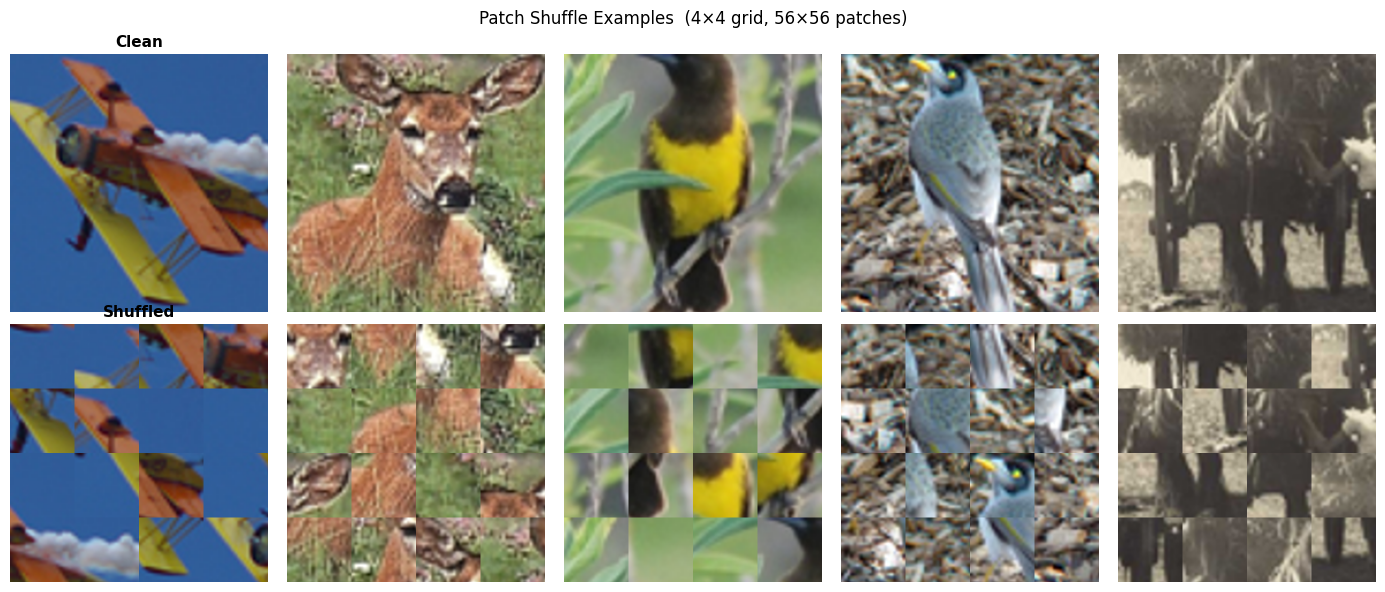

Saved → /content/drive/MyDrive/atml_assignment1/task1/results/step5_shuffle_examples.png


In [41]:
# ── Visual sanity check ───────────────────────────────────────────────────────

n_show = 5
fig, axes = plt.subplots(2, n_show, figsize=(14, 6))
idxs = np.linspace(0, len(EVAL_IMAGES) - 1, n_show, dtype=int)

for col, idx in enumerate(idxs):
    for row, (imgs, title) in enumerate([
        (EVAL_IMAGES,    'Clean'),
        (SHUFFLED_IMAGES,'Shuffled'),
    ]):
        img_np = imgs[idx].permute(1, 2, 0).numpy()
        img_np = np.clip(img_np, 0, 1)
        axes[row, col].imshow(img_np)
        axes[row, col].axis('off')
        if col == 0:
            axes[row, col].set_title(title, fontsize=11, fontweight='bold')

plt.suptitle('Patch Shuffle Examples  (4×4 grid, 56×56 patches)', fontsize=12)
plt.tight_layout()
viz_path = os.path.join(OUTPUT_DIR, 'step5_shuffle_examples.png')
plt.savefig(viz_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved → {viz_path}")

In [42]:
# ── Evaluate ──────────────────────────────────────────────────────────────────

PATCH_CACHE = os.path.join(OUTPUT_DIR, 'step5_patch_shuffle.json')

if os.path.exists(PATCH_CACHE):
    print("\nLoading cached patch-shuffle results...")
    with open(PATCH_CACHE) as f:
        patch_results = json.load(f)
    print("  Done.")

else:
    clean_preds = {
        'resnet_linear' : np.array(baseline_results['resnet_linear']['predictions']),
        'vit_linear'    : np.array(baseline_results['vit_linear']['predictions']),
        'clip_linear'   : np.array(baseline_results['clip_linear']['predictions']),
        'clip_zeroshot' : np.array(baseline_results['clip_zeroshot']['predictions']),
    }

    patch_results = {}
    configs = [
        ('resnet', 'linear'),
        ('vit',    'linear'),
        ('clip',   'linear'),
        ('clip',   'zeroshot'),
    ]

    for model_name, eval_type in configs:
        key = f'{model_name}_{eval_type}'

        if eval_type == 'linear':
            res = evaluate(model_name, SHUFFLED_IMAGES, EVAL_LABELS,
                           head=heads[model_name])
        else:
            res = evaluate_clip_zeroshot(SHUFFLED_IMAGES, EVAL_LABELS)

        clean_acc  = baseline_results[key]['accuracy']
        cons       = prediction_consistency(clean_preds[key],
                                            res['predictions'])
        acc_drop   = res['accuracy'] - clean_acc

        patch_results[key] = {
            'clean_accuracy'   : float(clean_acc),
            'shuffled_accuracy': float(res['accuracy']),
            'accuracy_drop'    : float(acc_drop),
            'consistency'      : float(cons),
            'predictions'      : res['predictions'],
        }

        print(f"  {key:22s} | clean={clean_acc:.4f} | "
              f"shuffled={res['accuracy']:.4f} | "
              f"drop={acc_drop:+.4f} | cons={cons:.4f}")

    with open(PATCH_CACHE, 'w') as f:
        json.dump({k: {kk: vv for kk, vv in v.items()
                       if kk != 'predictions'}
                   for k, v in patch_results.items()}, f, indent=2)
    print(f"\n  Saved → {PATCH_CACHE}")


Loading cached patch-shuffle results...
  Done.


In [43]:
# ── Summary table ─────────────────────────────────────────────────────────────

LABELS_MAP = {
    'resnet_linear' : 'ResNet-50   (linear)',
    'vit_linear'    : 'ViT-B/16    (linear)',
    'clip_linear'   : 'CLIP ViT-B/32 (linear)',
    'clip_zeroshot' : 'CLIP ViT-B/32 (zero-shot)',
}

print("\n" + "=" * 72)
print("  PATCH SHUFFLE SUMMARY")
print("=" * 72)
print(f"  {'Model':<30} {'Clean':>8} {'Shuffled':>10} {'Drop':>8} {'Cons':>8}")
print("  " + "-" * 68)
for key, label in LABELS_MAP.items():
    r = patch_results[key]
    print(f"  {label:<30} "
          f"{r['clean_accuracy']:>8.4f} "
          f"{r['shuffled_accuracy']:>10.4f} "
          f"{r['accuracy_drop']:>+8.4f} "
          f"{r['consistency']:>8.4f}")
print("=" * 72)


  PATCH SHUFFLE SUMMARY
  Model                             Clean   Shuffled     Drop     Cons
  --------------------------------------------------------------------
  ResNet-50   (linear)             0.9600     0.9000  -0.0600   0.9240
  ViT-B/16    (linear)             0.9720     0.8920  -0.0800   0.9020
  CLIP ViT-B/32 (linear)           0.9620     0.7640  -0.1980   0.7700
  CLIP ViT-B/32 (zero-shot)        0.9340     0.7420  -0.1920   0.7520


In [44]:
# ── Step 6: Representation Analysis ─────────────────────────────────────────

# ── 6.0  Dependencies ────────────────────────────────────────────────────────
try:
    import umap as umap_module
except ImportError:
    import subprocess
    subprocess.run(["pip", "install", "umap-learn", "-q"], check=True)
    import umap as umap_module

from torchvision.transforms.functional import rgb_to_grayscale
from matplotlib.lines import Line2D

STL10_CLASSES = ['airplane','bird','car','cat','deer',
                 'dog','horse','monkey','ship','truck']
CLASS_COLORS  = plt.cm.tab10(np.linspace(0, 1, 10))

In [45]:
# ── 6.1  Feature extraction helpers ─────────────────────────────────────────

@torch.no_grad()
def extract_features(backbone_name: str,
                     images: torch.Tensor,
                     batch_size: int = 64) -> np.ndarray:
    """
    Return (N, D) backbone features before the classifier head.
    ResNet-50  → 2048-dim GAP
    ViT-B/16   → 768-dim CLS token
    CLIP       → 512-dim L2-normalised embedding
    """
    model = backbones[backbone_name]
    norm  = NORM[backbone_name]
    model.eval()
    feats = []
    for i in range(0, len(images), batch_size):
        batch   = images[i:i + batch_size]
        batch_n = torch.stack([norm(img) for img in batch]).to(DEVICE)
        out = model(batch_n).cpu()
        if backbone_name == 'clip':
            out = out / (out.norm(dim=-1, keepdim=True) + 1e-8)
        feats.append(out)
    return torch.cat(feats, dim=0).numpy()


def cosine_stability(fc: np.ndarray, ft: np.ndarray) -> float:
    """
    IT = (1/N) Σ cos(f(xi), f(T(xi)))
    fc, ft: (N, D) — must be the same length (paired images).
    """
    eps  = 1e-8
    fc_n = fc / (np.linalg.norm(fc, axis=1, keepdims=True) + eps)
    ft_n = ft / (np.linalg.norm(ft, axis=1, keepdims=True) + eps)
    return float(np.mean((fc_n * ft_n).sum(axis=1)))

In [46]:
# ── 6.2  Prepare transformed image sets ──────────────────────────────────────
EVAL_LABELS_NP = np.array(EVAL_LABELS)

# (a) Grayscale — remove colour, keep geometry
GRAY_R6 = rgb_to_grayscale(EVAL_IMAGES, num_output_channels=1
                            ).expand(-1, 3, -1, -1).clone()

# (b) Translation δ=32 — use 'right' as the representative direction
TRANS32 = apply_translation(EVAL_IMAGES, 32, 'right')

# (c) Patch shuffle — SHUFFLED_IMAGES already computed in Step 5

# (d) Cue conflict — use exact content images stored in Step 3 metadata


CC_CLEAN = torch.stack([EVAL_IMAGES[d["eval_content_idx"]]
                        for d in cue_conflicts])
CC_CLEAN_LABELS = torch.tensor([d["content_cls"]
                                 for d in cue_conflicts])
print(f"CC content (exact): {CC_CLEAN.shape}   CC stylized: {CC_IMAGES.shape}")

CC content (exact): torch.Size([246, 3, 224, 224])   CC stylized: torch.Size([246, 3, 224, 224])


In [47]:
import open_clip

backbones = {
    'resnet': resnet,
    'vit'   : vit,
    'clip'  : clip_model.visual,
}

# Normalisation transforms (same as used in all earlier steps)
from torchvision import transforms as T
NORM = {
    'resnet': T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
    'vit'   : T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
    'clip'  : T.Normalize([0.48145466,0.4578275,0.40821073],
                          [0.26862954,0.26130258,0.27577711]),
}

print("backbones ready:", list(backbones.keys()))

backbones ready: ['resnet', 'vit', 'clip']


In [48]:
# ── 6.3  Extract / cache all features ────────────────────────────────────────

REP_CACHE = os.path.join(OUTPUT_DIR, 'step6_features.npz')

if os.path.exists(REP_CACHE):
    print("Loading cached features...")
    cached = np.load(REP_CACHE)
    feats  = {k: cached[k] for k in cached.files}
    print(f"  Loaded {len(feats)} arrays.")
else:
    print("Extracting features...")
    feats = {}
    for bb in ['resnet', 'vit', 'clip']:
        print(f"  {bb} ...", end=' ', flush=True)
        feats[f'{bb}_clean']    = extract_features(bb, EVAL_IMAGES)
        feats[f'{bb}_gray']     = extract_features(bb, GRAY_R6)
        feats[f'{bb}_trans']    = extract_features(bb, TRANS32)
        feats[f'{bb}_shuffle']  = extract_features(bb, SHUFFLED_IMAGES)
        feats[f'{bb}_cc_clean'] = extract_features(bb, CC_CLEAN)
        feats[f'{bb}_cc']       = extract_features(bb, CC_IMAGES)
        print(f"done  (clean={feats[f'{bb}_clean'].shape})")
    np.savez(REP_CACHE, **feats)
    print(f"  Saved → {REP_CACHE}")

Loading cached features...
  Loaded 18 arrays.


In [49]:
# ── 6.4  Cosine stability table ───────────────────────────────────────────────
TRANSFORMS_CS = {
    'Grayscale'       : ('clean',    'gray'),
    'Cue Conflict'    : ('cc_clean', 'cc'),
    'Translation δ=32': ('clean',    'trans'),
    'Patch Shuffle'   : ('clean',    'shuffle'),
}

print("\n" + "=" * 62)
print("  COSINE STABILITY   IT = mean cos( f(x), f(T(x)) )")
print("  (1.0 = identical representation  ·  lower = more disrupted)")
print("=" * 62)
print(f"  {'Transformation':<22} {'ResNet-50':>10} {'ViT-B/16':>10} {'CLIP':>10}")
print("  " + "-" * 55)

stability = {}
for t_name, (src, tgt) in TRANSFORMS_CS.items():
    row = {}
    for bb in ['resnet', 'vit', 'clip']:
        it = cosine_stability(feats[f'{bb}_{src}'], feats[f'{bb}_{tgt}'])
        row[bb] = it
    stability[t_name] = row
    print(f"  {t_name:<22} {row['resnet']:>10.4f} {row['vit']:>10.4f} "
          f"{row['clip']:>10.4f}")

print("=" * 62)

with open(os.path.join(OUTPUT_DIR, 'step6_cosine_stability.json'), 'w') as f:
    json.dump(stability, f, indent=2)


  COSINE STABILITY   IT = mean cos( f(x), f(T(x)) )
  (1.0 = identical representation  ·  lower = more disrupted)
  Transformation          ResNet-50   ViT-B/16       CLIP
  -------------------------------------------------------
  Grayscale                  0.7744     0.7292     0.8945
  Cue Conflict               0.2734     0.1616     0.6856
  Translation δ=32           0.9042     0.9446     0.9622
  Patch Shuffle              0.7013     0.6583     0.7231


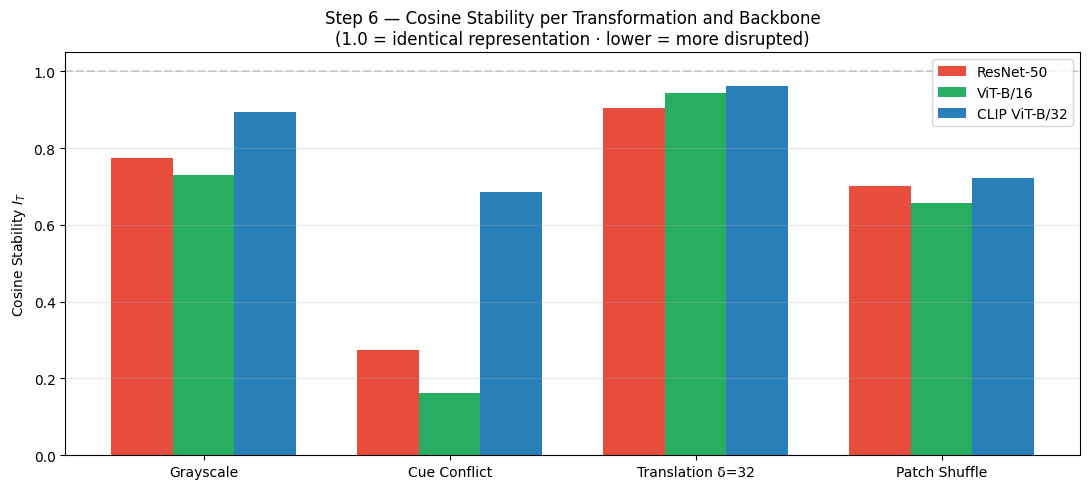

Saved → /content/drive/MyDrive/atml_assignment1/task1/results/step6_cosine_stability_bar.png


In [50]:
# ──  Cosine stability bar chart ─────────────────────────────────────

transforms_list = list(stability.keys())
backbones_list  = ['resnet', 'vit', 'clip']
bb_labels       = ['ResNet-50', 'ViT-B/16', 'CLIP ViT-B/32']
colors          = ['#e74c3c', '#27ae60', '#2980b9']

x = np.arange(len(transforms_list))
w = 0.25

fig, ax = plt.subplots(figsize=(11, 5))
for i, (bb, label, color) in enumerate(zip(backbones_list, bb_labels, colors)):
    vals = [stability[t][bb] for t in transforms_list]
    bars = ax.bar(x + (i-1)*w, vals, w, label=label, color=color)

ax.set_xticks(x)
ax.set_xticklabels(transforms_list, fontsize=10)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Cosine Stability $I_T$')
ax.set_title('Step 6 — Cosine Stability per Transformation and Backbone\n'
             '(1.0 = identical representation · lower = more disrupted)')
ax.axhline(1.0, color='gray', linestyle='--', alpha=0.3)
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
path = os.path.join(OUTPUT_DIR, 'step6_cosine_stability_bar.png')
plt.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved → {path}")

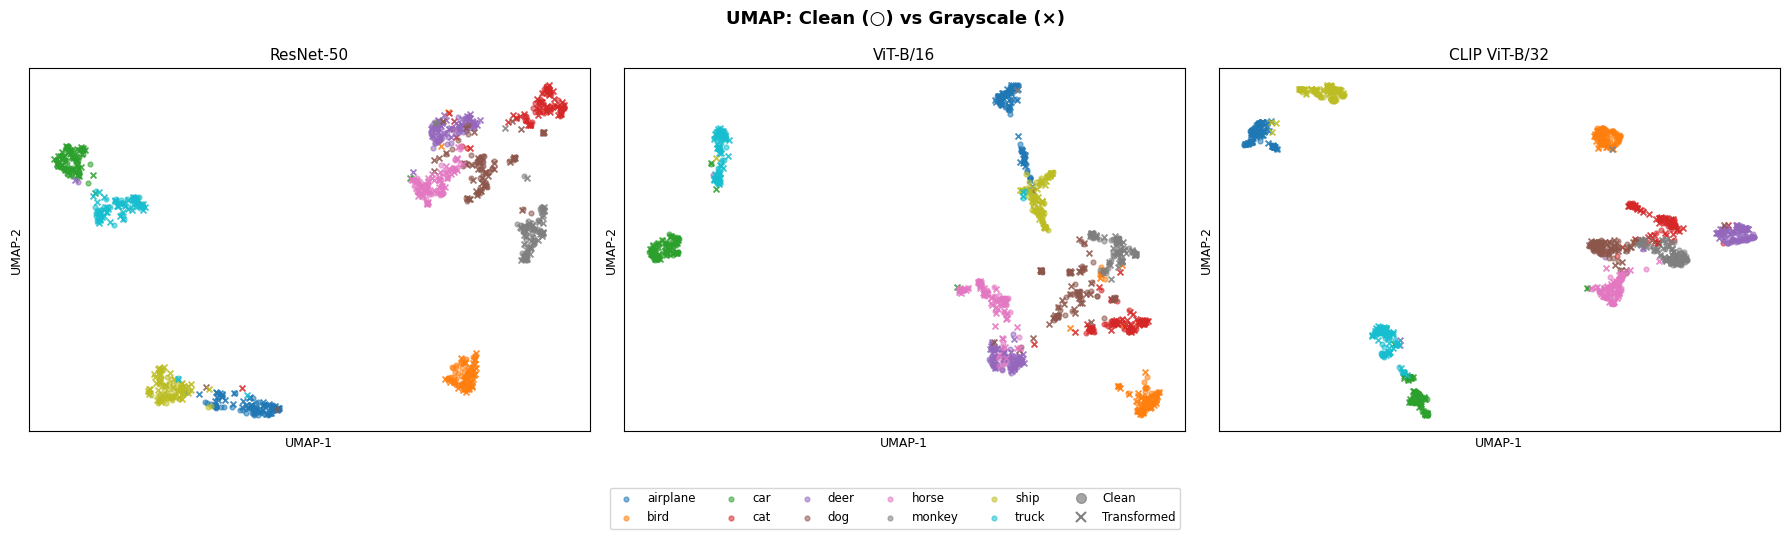

Saved → /content/drive/MyDrive/atml_assignment1/task1/results/step6_umap_grayscale.png


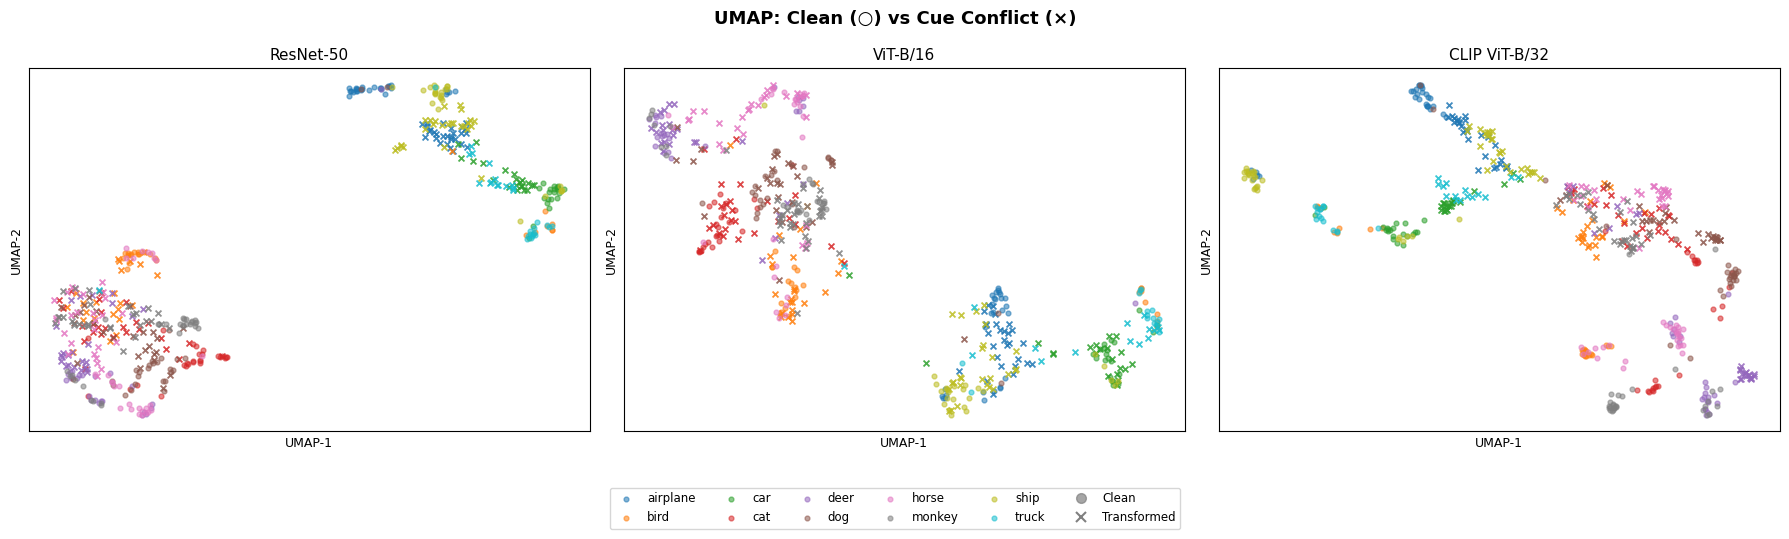

Saved → /content/drive/MyDrive/atml_assignment1/task1/results/step6_umap_cue_conflict.png


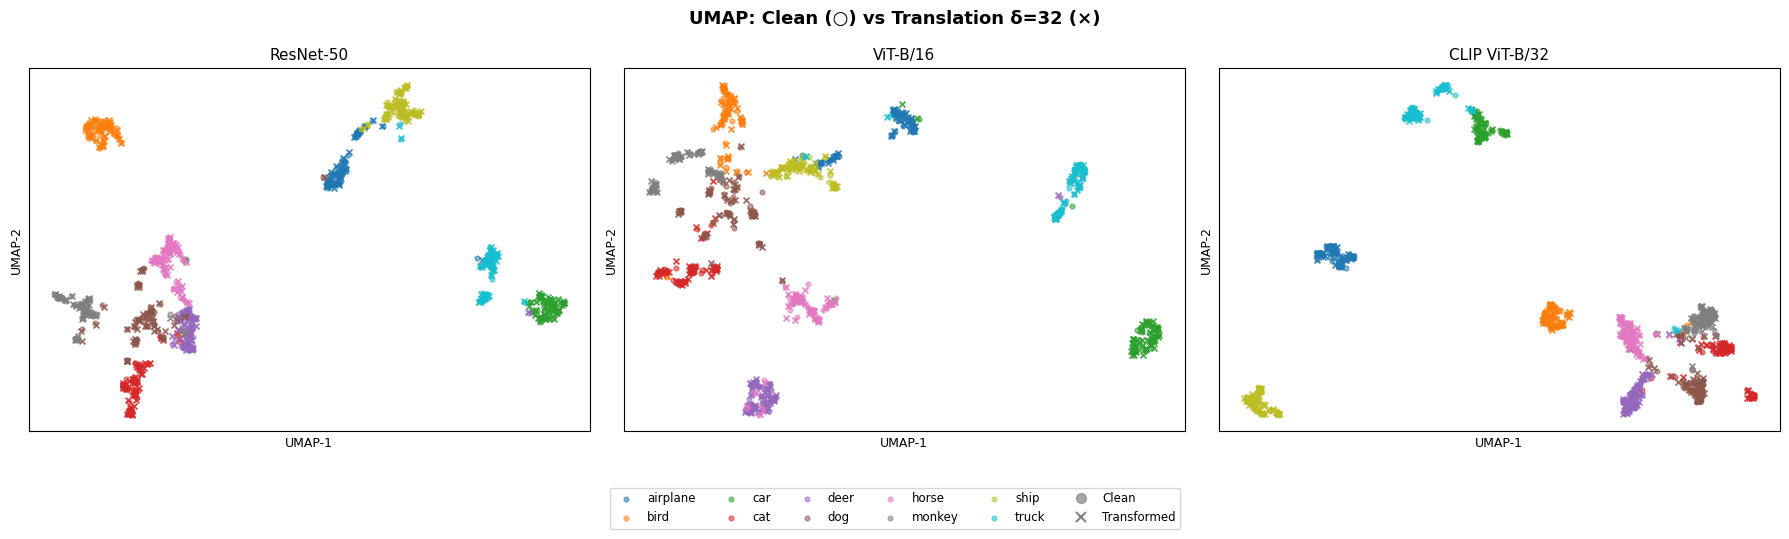

Saved → /content/drive/MyDrive/atml_assignment1/task1/results/step6_umap_translation_δ32.png


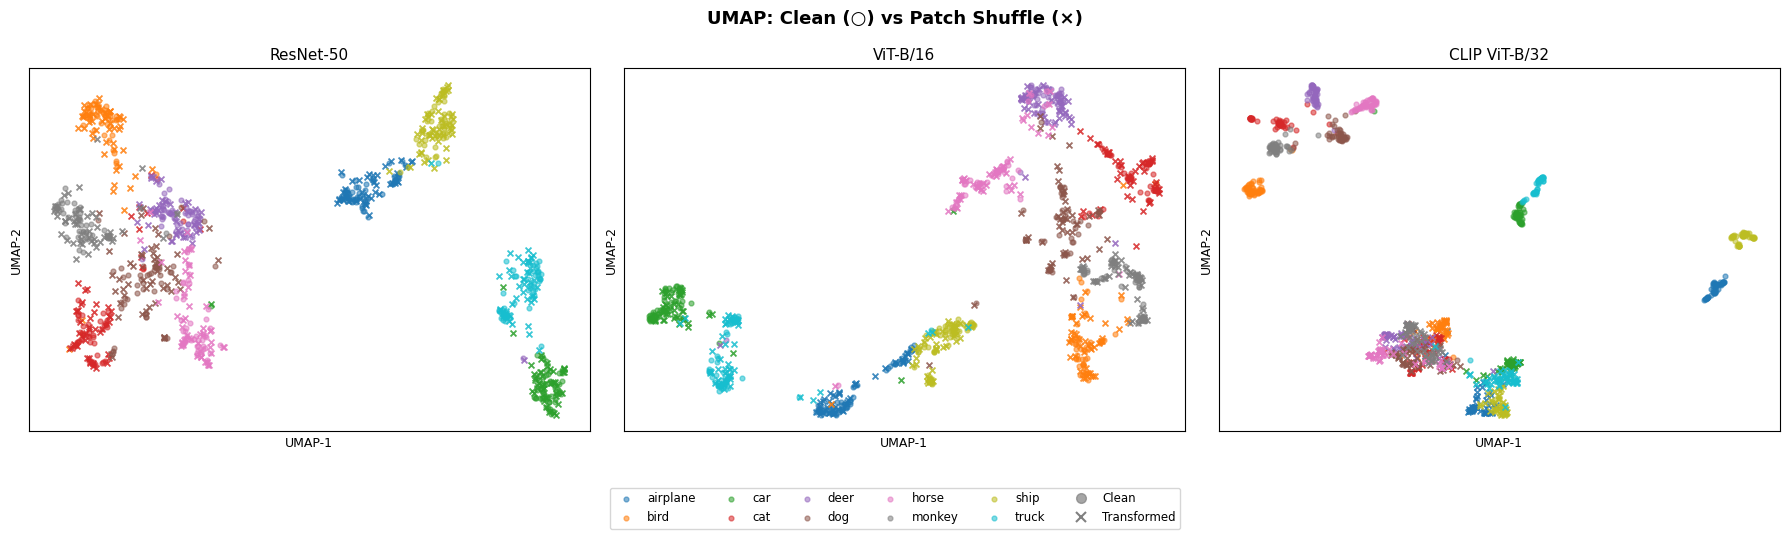

Saved → /content/drive/MyDrive/atml_assignment1/task1/results/step6_umap_patch_shuffle.png

Step 6 complete.


In [51]:
# ── 6.5  UMAP visualization ───────────────────────────────────────────────────

VIZ_SPECS = {
    'Grayscale'       : ('clean','gray',    EVAL_LABELS_NP, EVAL_LABELS_NP),
    'Cue Conflict'    : ('cc_clean','cc',   CC_CLEAN_LABELS, CC_CLEAN_LABELS),
    'Translation δ=32': ('clean','trans',   EVAL_LABELS_NP, EVAL_LABELS_NP),
    'Patch Shuffle'   : ('clean','shuffle', EVAL_LABELS_NP, EVAL_LABELS_NP),
}
BB_TITLES = {'resnet':'ResNet-50','vit':'ViT-B/16','clip':'CLIP ViT-B/32'}

for t_name, (src, tgt, lbl_c, lbl_t) in VIZ_SPECS.items():
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'UMAP: Clean (○) vs {t_name} (×)', fontsize=13,
                 fontweight='bold')

    for col, bb in enumerate(['resnet','vit','clip']):
        ax  = axes[col]
        fc  = feats[f'{bb}_{src}']
        ft  = feats[f'{bb}_{tgt}']

        combined = np.concatenate([fc, ft], axis=0)
        n_c, n_t = len(fc), len(ft)

        reducer = umap_module.UMAP(n_components=2, n_neighbors=15,
                                    min_dist=0.1, random_state=6304,
                                    verbose=False)
        emb      = reducer.fit_transform(combined)
        emb_c    = emb[:n_c]
        emb_t    = emb[n_c:]

        for cls_idx in range(10):
            col_rgb = CLASS_COLORS[cls_idx]
            mc = lbl_c == cls_idx
            mt = lbl_t == cls_idx
            if mc.any():
                ax.scatter(emb_c[mc, 0], emb_c[mc, 1],
                           c=[col_rgb], marker='o', s=12, alpha=0.55,
                           label=STL10_CLASSES[cls_idx] if col == 0 else '')
            if mt.any():
                ax.scatter(emb_t[mt, 0], emb_t[mt, 1],
                           c=[col_rgb], marker='x', s=18, alpha=0.85,
                           linewidths=1.3)

        ax.set_title(BB_TITLES[bb], fontsize=11)
        ax.set_xlabel('UMAP-1', fontsize=9)
        ax.set_ylabel('UMAP-2', fontsize=9)
        ax.tick_params(left=False, bottom=False,
                       labelleft=False, labelbottom=False)

    # Legend: classes + marker types
    handles, lbls = axes[0].get_legend_handles_labels()
    handles += [
        Line2D([0],[0], marker='o', color='gray', ls='', ms=7, alpha=0.7,
               label='Clean'),
        Line2D([0],[0], marker='x', color='gray', ls='', ms=7,
               markeredgewidth=1.5, label='Transformed'),
    ]
    lbls += ['Clean', 'Transformed']
    fig.legend(handles, lbls, loc='lower center', ncol=6,
               fontsize=8.5, bbox_to_anchor=(0.5, -0.07))

    plt.tight_layout(rect=[0, 0.07, 1, 1])
    safe = t_name.lower().replace(' ','_').replace('=','').replace('/','')
    path = os.path.join(OUTPUT_DIR, f'step6_umap_{safe}.png')
    plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved → {path}")

print("\nStep 6 complete.")